# Targeted Investigation into DEGs
Looking closer into DEGs with gene targets/genes of interest with the [new reference genome](https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_053477285.1/)

# Phase 2 vs. Phase 2

## 0. load libraries

In [2]:
library(tidyverse) # for dplyr, stringr, ggplot
library(KEGGREST) # for KEGG pathways
library(multcompView) # for stat labels on ggplot
library(GO.db)
library(AnnotationDbi)

## 1. load CSVs

### meta data

In [11]:
meta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv') %>%
mutate(complete_trtmt  = paste0(Phase1_treatment, '_', Phase2_treatment)) %>%
filter(!is.na(Phase2_treatment)) %>% # remove phase 1 samples
dplyr::select(Sample, Phase1_temp, Phase1_DO, Phase1_treatment, Phase2_temp, Phase2_DO, Phase2_treatment, complete_trtmt)

head(meta)

,Sample,Phase1_temp,Phase1_DO,Phase1_treatment,Phase2_temp,Phase2_DO,Phase2_treatment,complete_trtmt
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,B1_B1_O01,warm,hypoxic,both,warm,hypoxic,both,both_both
2,B1_W5_O50,warm,hypoxic,both,warm,normoxic,warm,both_warm
3,B2_B5_O51,warm,hypoxic,both,warm,hypoxic,both,both_both
4,B2_C4_O40,warm,hypoxic,both,ambient,normoxic,control,both_control
5,B3_B4_O41,warm,hypoxic,both,warm,hypoxic,both,both_both
6,B3_C3_O30,warm,hypoxic,both,ambient,normoxic,control,both_control


#### growth data

In [8]:
p2_growth <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/growth_phase2.1_weights.csv')

# add leading zeros to single digit tag num
p2_growth$Tag_num <- sprintf("%02d", p2_growth$Tag_num)

# make sample names same as my convention
p1_str <- str_sub(p2_growth$Phase_1_treat, 1, 1)
p2_str <- str_sub(p2_growth$Phase_2_treat, 1, 1)
p2_growth$Sample <- paste0(p1_str, p2_growth$Phase_1_rep, '_', p2_str, p2_growth$Phase_2_rep, '_', p2_growth$Tag_color, p2_growth$Tag_num)

# select the columns of interest
p2_growth <- p2_growth %>%
dplyr::select(Sample, Actual_shell_growth_mg, Actual_tissue_growth_mg, Ratio_tissue_shell_mg)

head(p2_growth)

,Sample,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg
,<chr>,<dbl>,<dbl>,<chr>
1,B1_B1_O01,210.27552,120.72448,0.574125224
2,B1_B1_O02,269.01966,72.58034,0.269795672
3,B1_B2_O13,418.96764,124.23236,0.29652018
4,B1_B2_O14,285.32868,148.97132,0.522104262
5,B1_B3_O25,75.84486,20.65514,0.272334078
6,B1_B3_O26,182.09100,44.30900,0.243334377


#### merge meta and growth data

In [13]:
metaData <- merge(meta, p2_growth, by = 'Sample')
head(metaData)

,Sample,Phase1_temp,Phase1_DO,Phase1_treatment,Phase2_temp,Phase2_DO,Phase2_treatment,complete_trtmt,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,B1_B1_O01,warm,hypoxic,both,warm,hypoxic,both,both_both,210.2755,120.72448,0.574125224
2,B1_W5_O50,warm,hypoxic,both,warm,normoxic,warm,both_warm,315.8883,85.61170,0.271018901
3,B2_B5_O51,warm,hypoxic,both,warm,hypoxic,both,both_both,114.3215,44.47852,0.389065292
4,B2_C4_O40,warm,hypoxic,both,ambient,normoxic,control,both_control,164.9903,55.10972,0.33401798
5,B3_B4_O41,warm,hypoxic,both,warm,hypoxic,both,both_both,197.9250,116.17500,0.586964759
6,B3_C3_O30,warm,hypoxic,both,ambient,normoxic,control,both_control,316.0466,241.35336,0.763663743


### all genes

In [14]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res',
    pattern = '\\.csv$',
    full.names = TRUE
    )

head(files)

[1] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bb_cc.csv"
[2] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bc_bb.csv"
[3] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bc_cc.csv"
[4] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bc_hc.csv"
[5] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bc_wc.csv"
[6] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bh_ch.csv"

In [15]:
names(files) <- tools::file_path_sans_ext(basename(files))
file_list <- lapply(files, read.csv)
names(file_list)

[1] "bb_cc" "bc_bb" "bc_cc" "bc_hc" "bc_wc" "bh_ch" "bh_hh" "bw_cw" "bw_ww"
[10] "cb_bb" "cb_bc" "cb_cc" "cb_ch" "cb_cw" "ch_cc" "ch_hc" "cw_cc" "cw_ch"
[19] "cw_wc" "hb_bb" "hb_bh" "hb_cb" "hc_cc" "hc_hh" "hh_cc" "hh_ch" "wb_bb"
[28] "wb_bw" "wb_cb" "wc_cc" "wc_hc" "wc_ww" "wh_hw" "ww_cc" "ww_cw"

In [16]:
head(file_list$bb_cc)

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1.973312e+03,-0.0332488130,0.10018698,0.82750435,0.4079513,0.8964045,0.9922542,2495.69160,2092.46282,⋯,2997.1598,989.093923,1560.977872,2330.6831,2070.68147,1769.86179,1994.901145,1739.660029,2926.81774,2569.347527
2,LOC144621269,2.477696e+03,-0.0078655573,0.14736612,0.62056406,0.5348865,0.9348872,0.9804099,52.27077,1648.11743,⋯,14829.0276,3.288758,7.480725,629.9143,41.13318,108.14038,10700.556957,17.774304,417.80514,10534.217403
3,LOC111120925,1.301645e+02,0.0085061583,0.15147791,-0.68050588,0.4961842,0.9239532,0.9787085,66.52643,23.22715,⋯,375.5976,0.000000,3.740362,459.2279,76.65728,29.97951,5.799131,1.110894,11.99963,9.671321
4,Trnae-cuc-2,1.043799e-02,0.0001907784,0.32997597,-0.01429643,0.9885935,NA,0.9752358,0.00000,0.00000,⋯,0.0000,0.000000,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000
5,Trnae-cuc-3,3.559860e-02,-0.0026528705,0.33519956,0.19674097,0.8440303,NA,0.9699419,0.00000,0.00000,⋯,0.0000,0.000000,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000
6,LOC144621283,8.712697e+02,-0.0037226610,0.09670776,0.08951601,0.9286718,0.9959300,0.9930926,540.76486,870.51301,⋯,604.2222,1004.715522,771.761424,893.0560,866.60123,794.45702,586.872081,1420.833446,596.70865,618.964524


### DEGs

In [17]:
deg_list <- lapply(file_list, function(df) {
  df %>% filter(abs(log2FoldChange) >= "1" & padj <= 0.05)
})

names(deg_list)
head(deg_list$bb_cc)

[1] "bb_cc" "bc_bb" "bc_cc" "bc_hc" "bc_wc" "bh_ch" "bh_hh" "bw_cw" "bw_ww"
[10] "cb_bb" "cb_bc" "cb_cc" "cb_ch" "cb_cw" "ch_cc" "ch_hc" "cw_cc" "cw_ch"
[19] "cw_wc" "hb_bb" "hb_bh" "hb_cb" "hc_cc" "hc_hh" "hh_cc" "hh_ch" "wb_bb"
[28] "wb_bw" "wb_cb" "wc_cc" "wc_hc" "wc_ww" "wh_hw" "ww_cc" "ww_cw"

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111102506,948.578114,1.113463,1.3782539,-3.721539,1.980124e-04,4.376733e-02,2.293073e-01,822.0766309,290.844253,⋯,112.13493,230.21305,275.54002,1135.877800,179.4902221,280.52256,796.800632,234.39864,285.80926,204.172325
2,LOC111117765,948.580792,1.019382,0.7028216,-4.035920,5.438871e-05,1.923475e-02,1.031210e-01,1030.2093271,726.100756,⋯,1376.10241,948.80664,354.08763,785.360948,624.4763979,619.93344,1457.901593,607.65903,376.35189,546.966914
3,LOC111104782,61.439122,1.360622,1.1165575,-3.947402,7.900399e-05,2.436630e-02,8.045647e-02,73.1790758,105.027091,⋯,39.19279,32.06539,92.26227,8.127927,183.2296018,26.76742,59.151139,36.65950,33.81713,8.596729
4,LOC144619911,263.266792,-3.777067,3.9685711,3.967465,7.264103e-05,2.349671e-02,1.289212e-01,0.0000000,20.197518,⋯,0.00000,2431.21424,1034.83357,1.015991,0.9348449,0.00000,2.319652,5.55447,4.36350,0.000000
5,LOC111105268,370.537252,-1.988343,2.3808844,3.881096,1.039866e-04,2.795036e-02,1.789722e-01,0.9503776,1852.112359,⋯,17.41902,204.72518,351.59406,42.671617,365.5243586,94.22132,336.349612,1969.61509,644.70715,53.729559
6,LOC111102028,7.951088,21.008371,3.3828306,-6.378646,1.786602e-10,2.961740e-07,6.332811e-07,0.0000000,3.029628,⋯,59.87787,12.33284,0.00000,1.015991,0.0000000,0.00000,0.000000,0.00000,0.00000,4.298365


## 2. Growth Genes

### Chitin Genes
In both vs. control there are four gene sets that are over-represented in relation to chitin (chitin binding, chitinase activity, chitin catabolic process, and polysaccharide catabolic process)

Want to pull these out, take a closer look, look at these in other comparisons against the both treatment and see if these genes are always affected

In [19]:
# read in gene ID to GO term file
gene2go <- read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ref_files/annotations/newRef_geneGO.csv')

# expand df so every row contains one GO and one gene ID
term2gene <- gene2go %>%
  mutate(GO_terms = strsplit(Gene.Ontology.IDs, ";")) %>%  # Split by comma, semicolon, or backtick
  unnest(GO_terms) %>%
  filter(grepl("^GO:", GO_terms)) %>%  # Keep only valid GO terms
  dplyr::select(term = GO_terms, gene = gene)

# Extract GO term descriptions
go_terms <- unique(term2gene$term)

# Get descriptions from GO.db
term2name <- data.frame(
  term = go_terms,
  name = sapply(go_terms, function(x) {
    tryCatch({
      Term(GOTERM[[x]])
    }, error = function(e) {
      NA_character_
    })
  })
)

# Remove NAs
term2name <- term2name[!is.na(term2name$name), ]

# View
head(term2name) 

,term,name
,<chr>,<chr>
GO:0005261,GO:0005261,monoatomic cation channel activity
GO:0005886,GO:0005886,plasma membrane
GO:0030001,GO:0030001,metal ion transport
GO:0098655,GO:0098655,monoatomic cation transmembrane transport
GO:0004930,GO:0004930,G protein-coupled receptor activity
GO:0007186,GO:0007186,G protein-coupled receptor signaling pathway


In [20]:
chitinGO <- term2name[grep('chitin', term2name$name, ignore.case = TRUE),]
chitinGO

,term,name
,<chr>,<chr>
GO:0004100,GO:0004100,chitin synthase activity
GO:0006031,GO:0006031,chitin biosynthetic process
GO:0008061,GO:0008061,chitin binding
GO:0004568,GO:0004568,chitinase activity
GO:0006032,GO:0006032,chitin catabolic process


In [21]:
# pull out genes related to chitinase activity
# GO:0004568
chitin_genes <- term2gene %>%
inner_join(chitinGO, by = 'term') %>%
distinct(gene, term, name)

chitin_genes

gene,term,name
<chr>,<chr>,<chr>
LOC111100586,GO:0004100,chitin synthase activity
LOC111100586,GO:0006031,chitin biosynthetic process
LOC111100662,GO:0008061,chitin binding
LOC111105678,GO:0008061,chitin binding
LOC111105812,GO:0004100,chitin synthase activity
LOC111105812,GO:0006031,chitin biosynthetic process
LOC111106095,GO:0008061,chitin binding
LOC111106155,GO:0008061,chitin binding
LOC111106230,GO:0004100,chitin synthase activity


In [22]:
# combining all dfs into one
combined.df <- do.call(rbind, deg_list) %>%
# add pair column from rowname
mutate(pair = sub("\\..*", "", rownames(.))) %>%
# add DEG group
  mutate(
    DEG_group = if_else(
      log2FoldChange > 0,
      str_extract(pair, "^[^_]+"),      # text before _
      str_extract(pair, "[^_]+$")       # text after _
    )
  )
dim(combined.df)

# pulling out only genes related to chitin
chitin_all <- combined.df[chitin_genes$gene %in% combined.df$Gene,]
dim(chitin_all)
head(chitin_all)

[1] 5998  104

[1] 735 104

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48,pair,DEG_group
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
bb_cc.8,LOC111101301,1028.169369,-8.079579,2.8203058,4.632872,3.606284e-06,2.125624e-03,9.175237e-03,0.9503776,62.612304,⋯,0.00000,1.015991,0.9348449,3889.841432,57.99131,28.883244,2.18175,22.566415,bb_cc,cc
bb_cc.11,LOC111101184,51.488143,1.613242,1.5623664,-3.907800,9.314017e-05,2.589756e-02,1.203116e-01,85.5339847,20.197518,⋯,9.97430,103.631069,21.5014329,35.332994,54.51183,19.996092,22.90838,6.447547,bb_cc,bb
bb_cc.13,LOC111127044,5.558968,-14.764961,2.4893964,6.023719,1.704542e-09,2.152917e-06,4.601303e-06,0.0000000,7.069131,⋯,0.00000,0.000000,0.0000000,4.282787,0.00000,0.000000,2.18175,6.447547,bb_cc,cc
bb_cc.42,LOC111100763,95.725514,-1.222357,1.0255598,3.921124,8.813692e-05,2.545769e-02,9.869068e-02,48.4692580,171.678899,⋯,188.26490,36.575672,155.1842546,103.857588,92.78610,76.651687,83.99738,42.983647,bb_cc,cc
bb_cc.43,LOC111136589,422.331672,2.051063,1.6235960,-4.052108,5.075825e-05,1.819340e-02,5.261467e-02,115.9460682,130.273988,⋯,206.96671,174.750431,107.5071643,88.867833,15.07774,145.527116,183.26701,283.692073,bb_cc,bb
bb_cc.44,LOC111104585,105.387767,1.091985,0.9561907,-3.882576,1.033558e-04,2.795036e-02,1.246190e-01,283.2125272,56.553049,⋯,31.16969,30.479726,107.5071643,185.230544,216.88751,9.998046,114.54188,39.759874,bb_cc,bb


there are 735 DEGs related to chitin in all phase 2 comparisons!

In [23]:
# add col that denotes pair with Both treatment
chitin_all2 <- chitin_all %>%
mutate(pair_B = if_else(
    grepl('b', rownames(.)), 'Yes', 'No')
       )

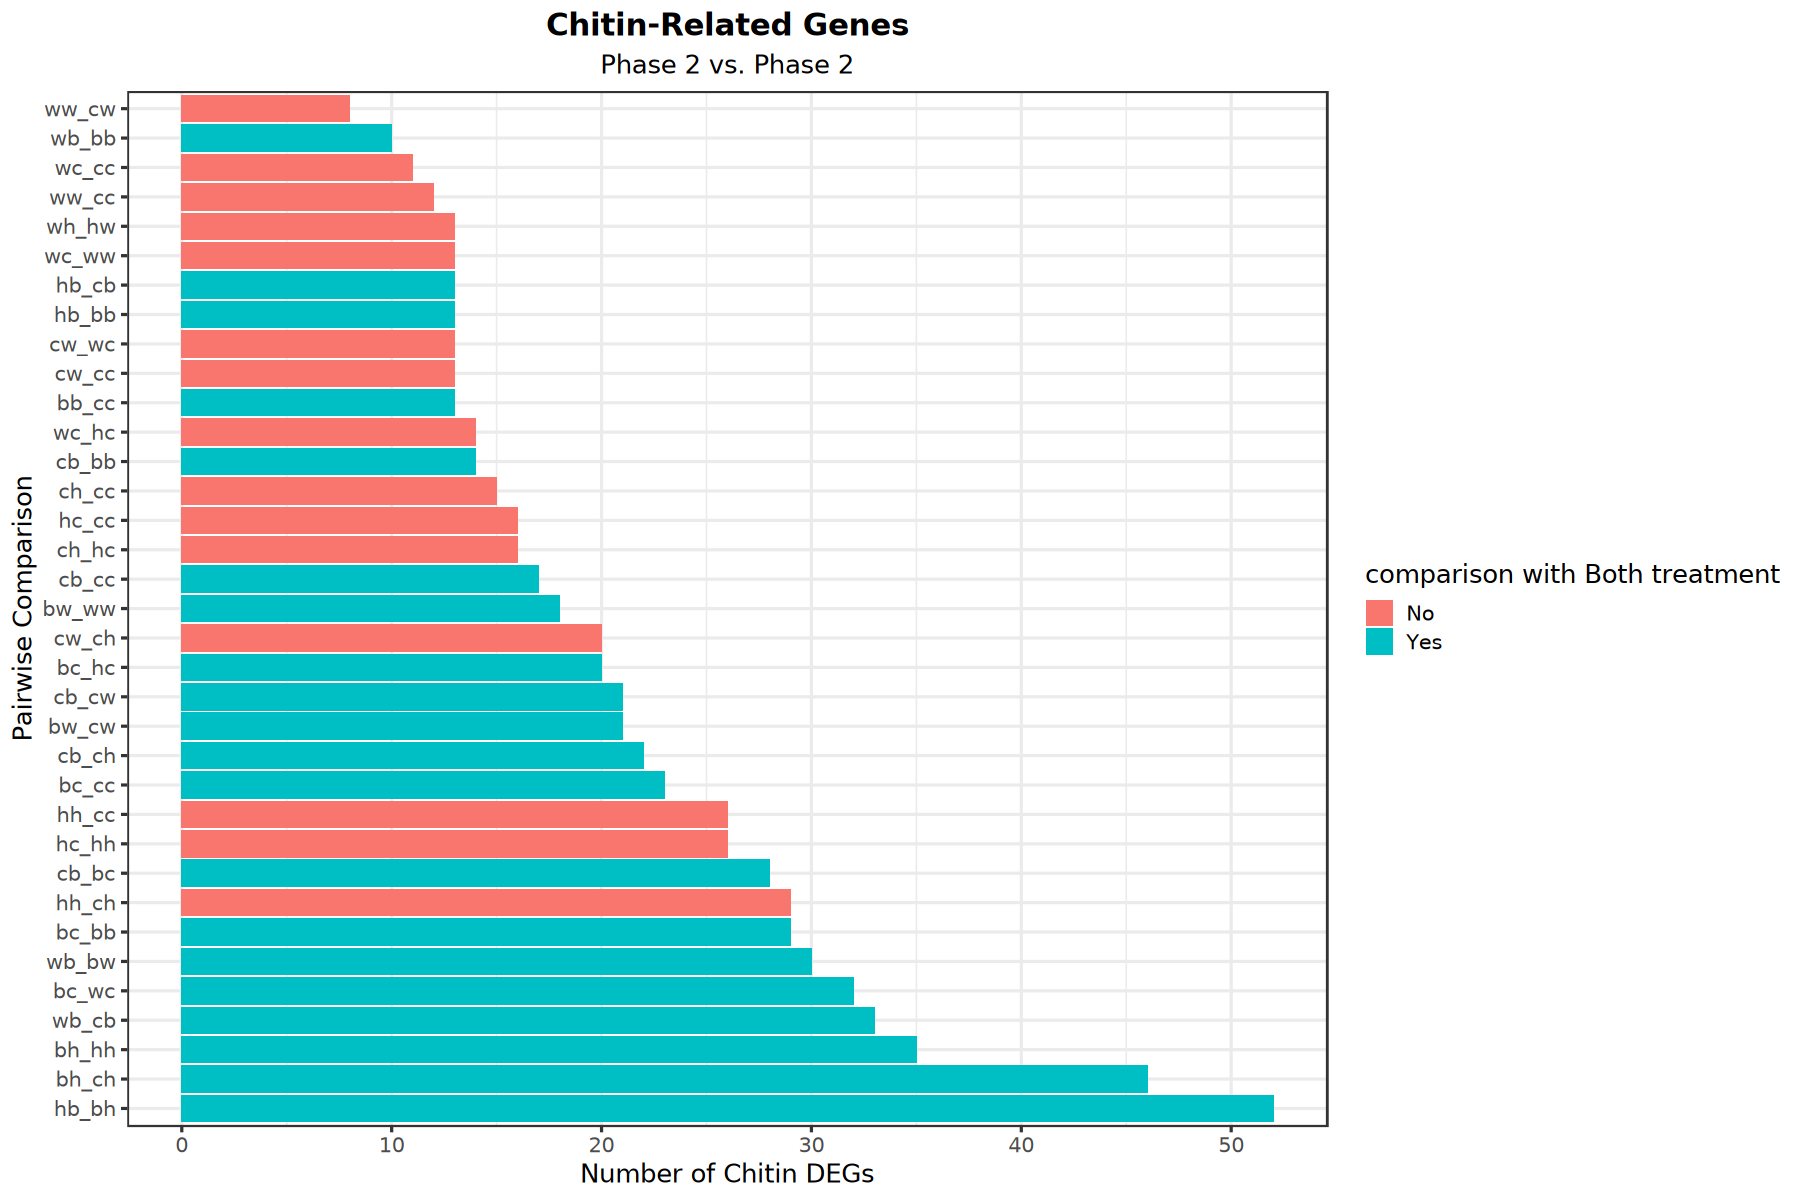

In [24]:
options(repr.plot.width=15, repr.plot.height=10)

chitin_bar <- ggplot(chitin_all2, aes(x = reorder(pair, -table(pair)[pair]), fill = pair_B)) +
geom_bar(stat = 'count') + 
#scale_fill_brewer(palette='Set2') + 
theme_bw(base_size=15) +
labs(title = 'Chitin-Related Genes',
     subtitle = 'Phase 2 vs. Phase 2',
     x = 'Pairwise Comparison',
     y = 'Number of Chitin DEGs',
    fill = 'comparison with Both treatment') +
theme(plot.title = element_text(face = 'bold', hjust = 0.5),
     plot.subtitle = element_text(hjust = 0.5)) + 
coord_flip() 

chitin_bar

majority of comparisons with chitin DEGs are comparisons with the both treatment

In [29]:
#ggsave('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/plots/chitin.genes_bar.pdf', chitin_bar, width = 15, height = 10)

In [25]:
# add col that denotes pair with Both treatment
chitin_all2 <- chitin_all %>%
mutate(pair_B = if_else(
    grepl('b', rownames(.)), 'contains both treatment', 'no both treatment')
       )

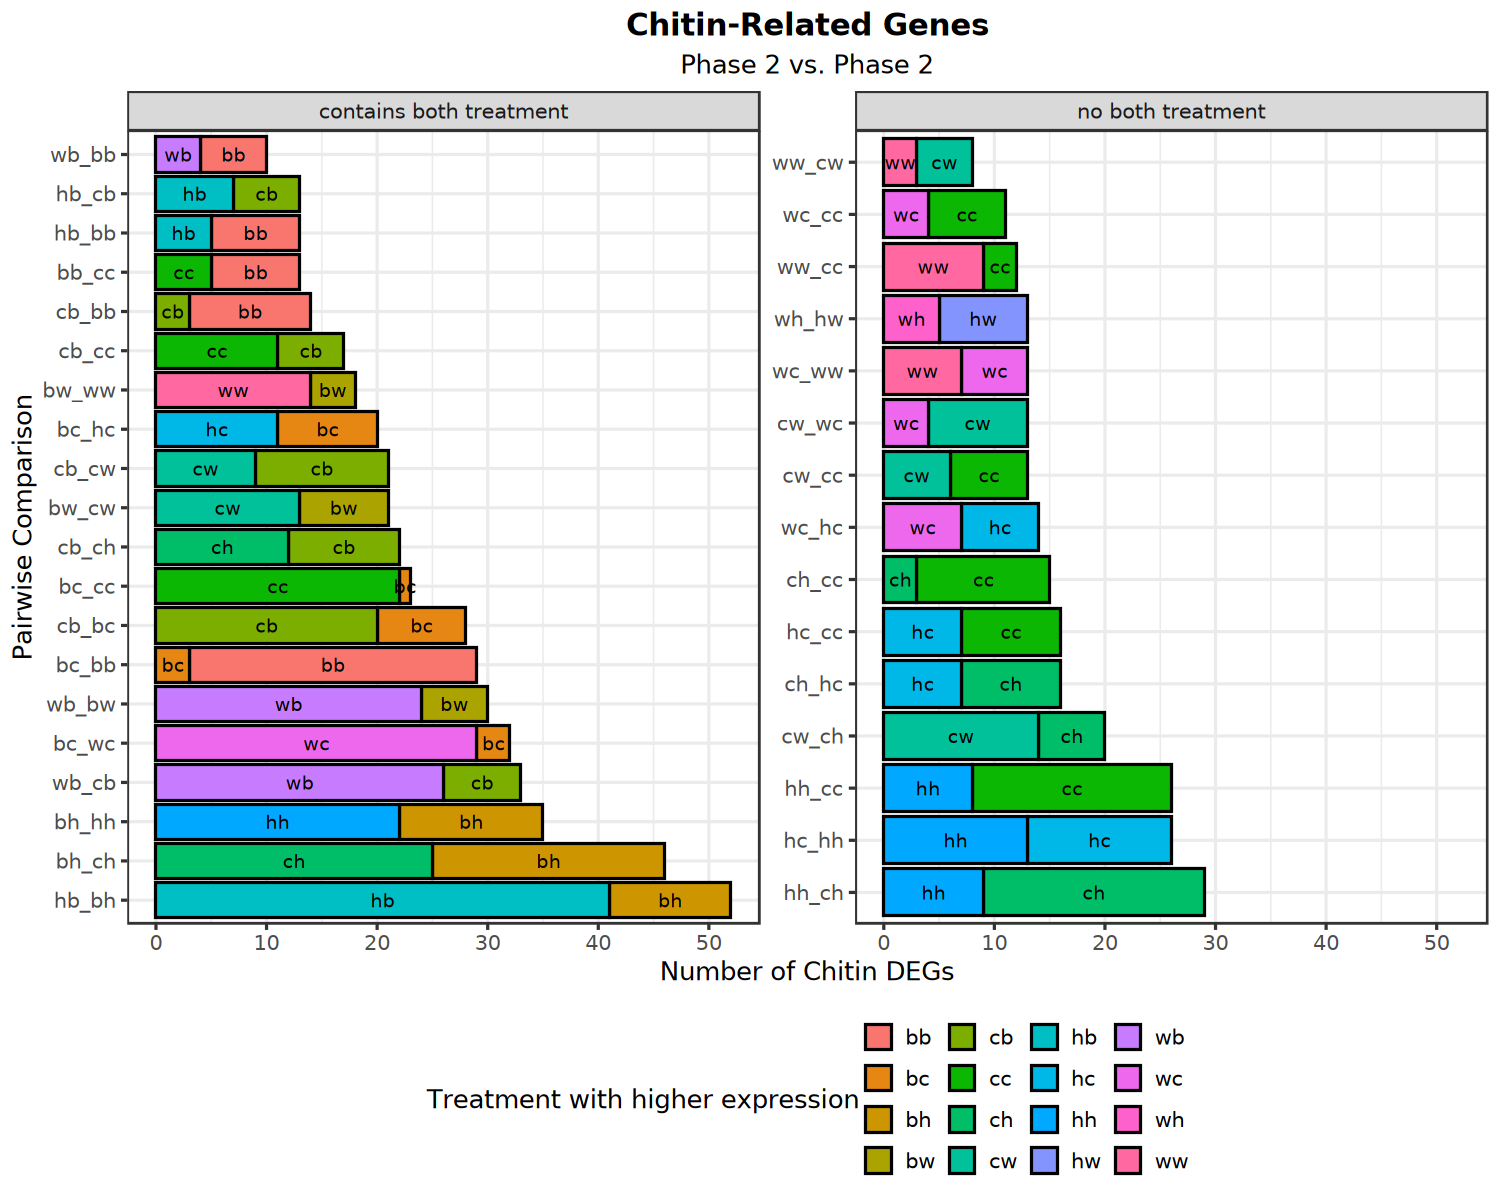

In [26]:
options(repr.plot.width=12.5, repr.plot.height=10)

chitin_bar <- ggplot(chitin_all2, aes(x = reorder(pair, -table(pair)[pair]), fill = DEG_group)) +
geom_bar(stat = 'count', col = 'black') + 
facet_wrap(~pair_B, scales = 'free_y') + 
#scale_fill_brewer(palette='Set2') + 
theme_bw(base_size=15) +
labs(title = 'Chitin-Related Genes',
     subtitle = 'Phase 2 vs. Phase 2',
     x = 'Pairwise Comparison',
     y = 'Number of Chitin DEGs',
    fill = 'Treatment with higher expression') +
geom_text(
    stat = "count",
    aes(label = DEG_group),
    position = position_stack(vjust = 0.5),
    color = "black",
    size = 4
  ) +
theme(legend.position = 'bottom', legend.direction = 'horizontal',
    plot.title = element_text(face = 'bold', hjust = 0.5),
     plot.subtitle = element_text(hjust = 0.5)) + 
coord_flip() 

chitin_bar

In [32]:
#ggsave('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/plots/chitin.genesDETAILED_bar.pdf', chitin_bar, width = 12.5, height = 10)

### LOC144619016
LOC144619016 is an uncharacterized gene on [NCBI](https://www.ncbi.nlm.nih.gov/gene/?term=LOC144619016), but comes up as a core enrichment gene for every comparison that was enriched for chitin binding in a [GSEA](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/new_refGenome/gsea_p2.v.p2.ipynb)

I want to investigate this a bit more and look at the expression of this gene between treatments

In [27]:
chitin_core <- file_list$bb_cc %>%
dplyr::select(-c(2:8)) %>%
  dplyr::filter(Gene == "LOC144619016") %>%
  dplyr::select(-Gene) %>%      # remove gene column
  t() %>%                   # transpose
  as.data.frame() %>%       # matrix → data.frame
  rownames_to_column("Sample") %>%
  dplyr::rename(vst_expr = V1)

chitin_core <- merge(chitin_core, metaData, by = 'Sample')

dim(chitin_core)
head(chitin_core)

[1] 92 12

,Sample,vst_expr,Phase1_temp,Phase1_DO,Phase1_treatment,Phase2_temp,Phase2_DO,Phase2_treatment,complete_trtmt,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg
,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,B1_B1_O01,0,warm,hypoxic,both,warm,hypoxic,both,both_both,210.2755,120.72448,0.574125224
2,B1_W5_O50,0,warm,hypoxic,both,warm,normoxic,warm,both_warm,315.8883,85.61170,0.271018901
3,B2_B5_O51,0,warm,hypoxic,both,warm,hypoxic,both,both_both,114.3215,44.47852,0.389065292
4,B2_C4_O40,0,warm,hypoxic,both,ambient,normoxic,control,both_control,164.9903,55.10972,0.33401798
5,B3_B4_O41,0,warm,hypoxic,both,warm,hypoxic,both,both_both,197.9250,116.17500,0.586964759
6,B3_C3_O30,0,warm,hypoxic,both,ambient,normoxic,control,both_control,316.0466,241.35336,0.763663743


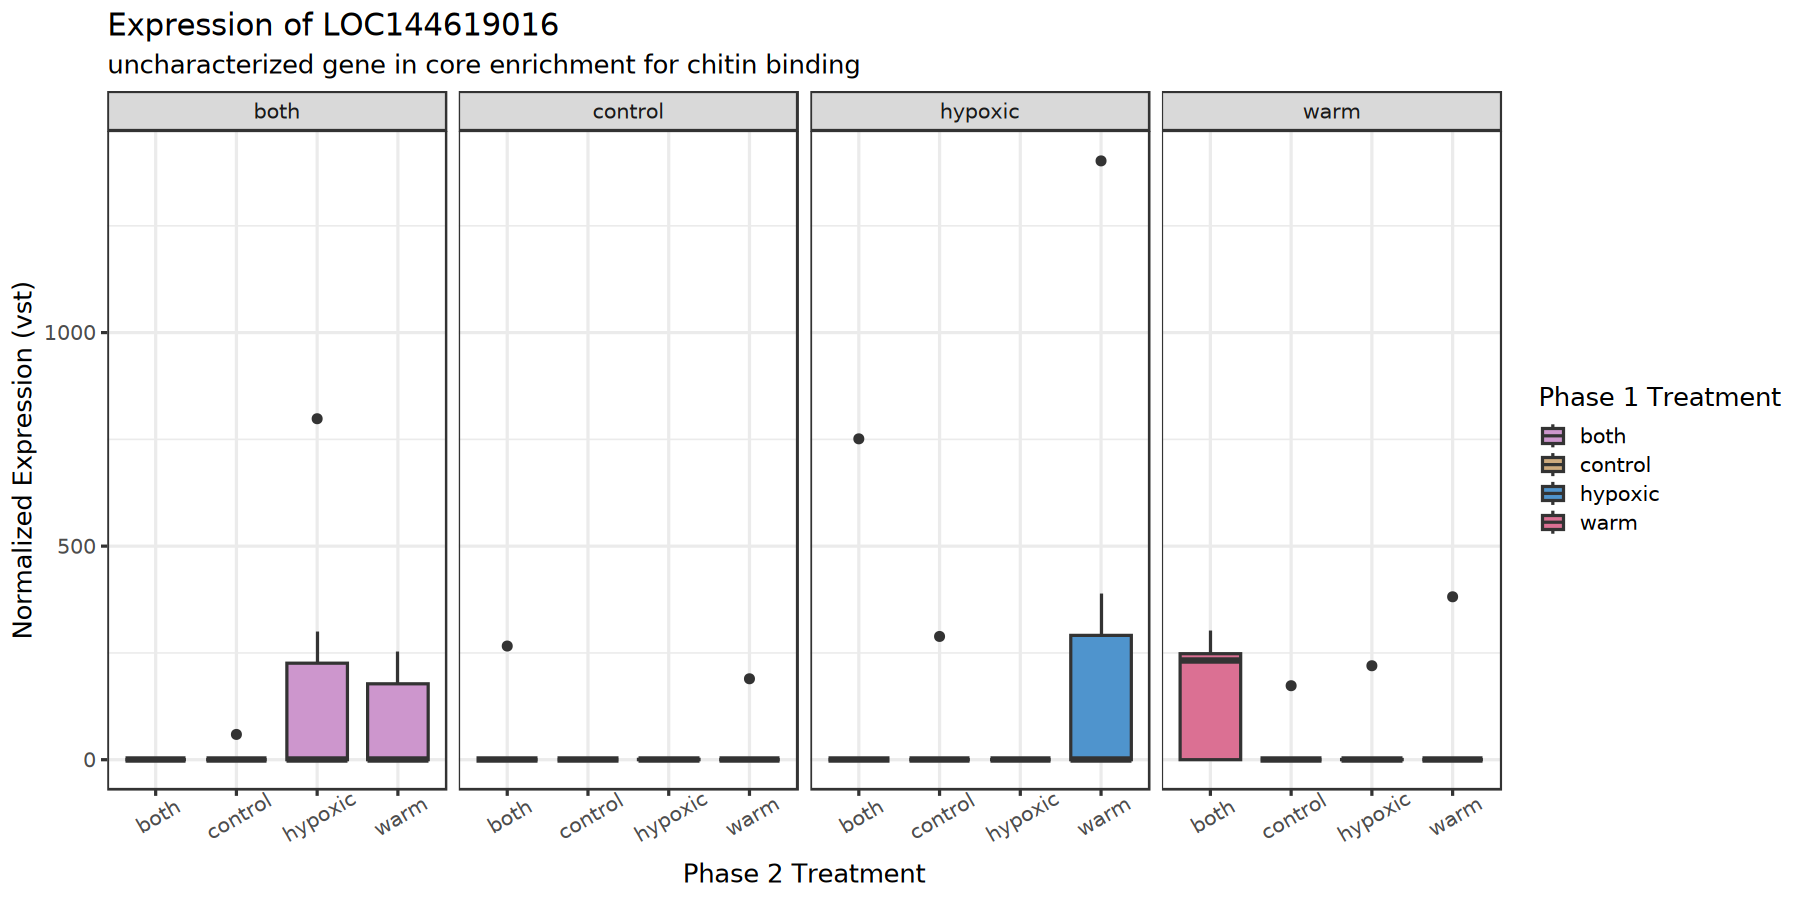

In [28]:
options(repr.plot.height = 7.5, repr.plot.width = 15)

ggplot(chitin_core, aes(x=Phase2_treatment, y = vst_expr, fill = Phase1_treatment)) +
geom_boxplot() +
scale_fill_manual(values = c("control" = "burlywood3", "hypoxic" = "steelblue3", "warm" = "palevioletred", "both" = "plum3")) + 
facet_wrap(~Phase1_treatment, nrow = 1) +
labs(title = 'Expression of LOC144619016',
    subtitle = 'uncharacterized gene in core enrichment for chitin binding',
    y = 'Normalized Expression (vst)',
    x = 'Phase 2 Treatment',
    fill = 'Phase 1 Treatment') +
theme_bw(base_size = 15) +
theme(axis.text.x = element_text(angle = 30, vjust = 0.8))

most oysters do not express this gene (except for a few outliers in most treatment combos) - but those that do have higher expression:
- BH
- BW
- HW
- WB (especially! actually has an average that is not 0)

In [29]:
chitin.aov <- aov(vst_expr ~ Phase1_DO * Phase1_temp * Phase2_DO * Phase2_temp, data = chitin_core)
summary(chitin.aov)

                                            Df  Sum Sq Mean Sq F value Pr(>F)
Phase1_DO                                    1   65950   65950   1.622  0.207
Phase1_temp                                  1      69      69   0.002  0.967
Phase2_DO                                    1     677     677   0.017  0.898
Phase2_temp                                  1   79504   79504   1.955  0.166
Phase1_DO:Phase1_temp                        1   56138   56138   1.380  0.244
Phase1_DO:Phase2_DO                          1   18470   18470   0.454  0.502
Phase1_temp:Phase2_DO                        1   55904   55904   1.375  0.245
Phase1_DO:Phase2_temp                        1      67      67   0.002  0.968
Phase1_temp:Phase2_temp                      1   68812   68812   1.692  0.197
Phase2_DO:Phase2_temp                        1   35236   35236   0.866  0.355
Phase1_DO:Phase1_temp:Phase2_DO              1   16452   16452   0.405  0.527
Phase1_DO:Phase1_temp:Phase2_temp            1  112599  112599  

when looking at the [volcano plots](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/new_refGenome/volcano_p2.v.p2.ipynb) of DEGs between pairwise comparisons, I found that this uncharacterized chitin gene was similarly differentially expressed against control oysters in HC, WC, and BC - I'm curious what the expression actually looks like between these

In [30]:
chitin_core %>%
filter(Phase2_treatment == 'control')

Sample,vst_expr,Phase1_temp,Phase1_DO,Phase1_treatment,Phase2_temp,Phase2_DO,Phase2_treatment,complete_trtmt,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
B2_C4_O40,0.00000,warm,hypoxic,both,ambient,normoxic,control,both_control,164.99028,55.10972,0.33401798
B3_C3_O30,0.00000,warm,hypoxic,both,ambient,normoxic,control,both_control,316.04664,241.35336,0.763663743
B3_C6_O66,0.00000,warm,hypoxic,both,ambient,normoxic,control,both_control,97.06242,22.23758,0.229105971
B4_C5_O56,59.15055,warm,hypoxic,both,ambient,normoxic,control,both_control,208.53378,95.26622,0.456838312
B6_C2_O24,0.00000,warm,hypoxic,both,ambient,normoxic,control,both_control,534.55584,179.34416,0.335501264
C1_C4_W37,0.00000,ambient,normoxic,control,ambient,normoxic,control,control_control,214.86738,125.73262,0.585163835
C2_C1_W03,0.00000,ambient,normoxic,control,ambient,normoxic,control,control_control,219.77592,98.02408,0.44601829
C3_C2_W17,0.00000,ambient,normoxic,control,ambient,normoxic,control,control_control,500.67108,259.22892,0.517762919
C4_C6_W67,0.00000,ambient,normoxic,control,ambient,normoxic,control,control_control,78.85332,35.34668,0.448258615


huh ... that's disappointing - it seems like it's just one sample in each stressor (HC, WC, and BC) that are driving those differences - otherwise, the vst expression is 0... I wonder if looking at TPM would be different? but also this makes me think I need to readjust how I'm running DESeq if this is coming up as DE in only one replicate for each treatment

### chitin binding and shell growth

In [32]:
chitin_binding <- chitin_genes %>% filter(name == 'chitin binding')

dim(chitin_binding) # 62 genes related to chitin binding
head(chitin_binding)

[1] 62  3

gene,term,name
<chr>,<chr>,<chr>
LOC111100662,GO:0008061,chitin binding
LOC111105678,GO:0008061,chitin binding
LOC111106095,GO:0008061,chitin binding
LOC111106155,GO:0008061,chitin binding
LOC111106396,GO:0008061,chitin binding
LOC111106838,GO:0008061,chitin binding


In [40]:
chitin_core <- file_list$bb_cc %>%
  dplyr::select(-c(2:8)) %>%
  dplyr::filter(Gene %in% chitin_binding$gene) %>%
  tidyr::pivot_longer(
    cols = -Gene,
    names_to = "Sample",
    values_to = "vst_expr"
  )

chitin_core <- merge(chitin_core, metaData, by = 'Sample')
head(chitin_core)
colnames(chitin_core)

,Sample,Gene,vst_expr,Phase1_temp,Phase1_DO,Phase1_treatment,Phase2_temp,Phase2_DO,Phase2_treatment,complete_trtmt,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,B1_B1_O01,LOC111135120,88.38512,warm,hypoxic,both,warm,hypoxic,both,both_both,210.2755,120.7245,0.574125224
2,B1_B1_O01,LOC111129343,16301.82711,warm,hypoxic,both,warm,hypoxic,both,both_both,210.2755,120.7245,0.574125224
3,B1_B1_O01,LOC111132129,32.31284,warm,hypoxic,both,warm,hypoxic,both,both_both,210.2755,120.7245,0.574125224
4,B1_B1_O01,LOC144627872,3.80151,warm,hypoxic,both,warm,hypoxic,both,both_both,210.2755,120.7245,0.574125224
5,B1_B1_O01,LOC111135614,73.17908,warm,hypoxic,both,warm,hypoxic,both,both_both,210.2755,120.7245,0.574125224
6,B1_B1_O01,LOC111107197,11.40453,warm,hypoxic,both,warm,hypoxic,both,both_both,210.2755,120.7245,0.574125224


[1] "Sample"                  "Gene"                   
 [3] "vst_expr"                "Phase1_temp"            
 [5] "Phase1_DO"               "Phase1_treatment"       
 [7] "Phase2_temp"             "Phase2_DO"              
 [9] "Phase2_treatment"        "complete_trtmt"         
[11] "Actual_shell_growth_mg"  "Actual_tissue_growth_mg"
[13] "Ratio_tissue_shell_mg"

In [52]:
library(ggrepel)

Warning message:
“ggrepel: 55 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


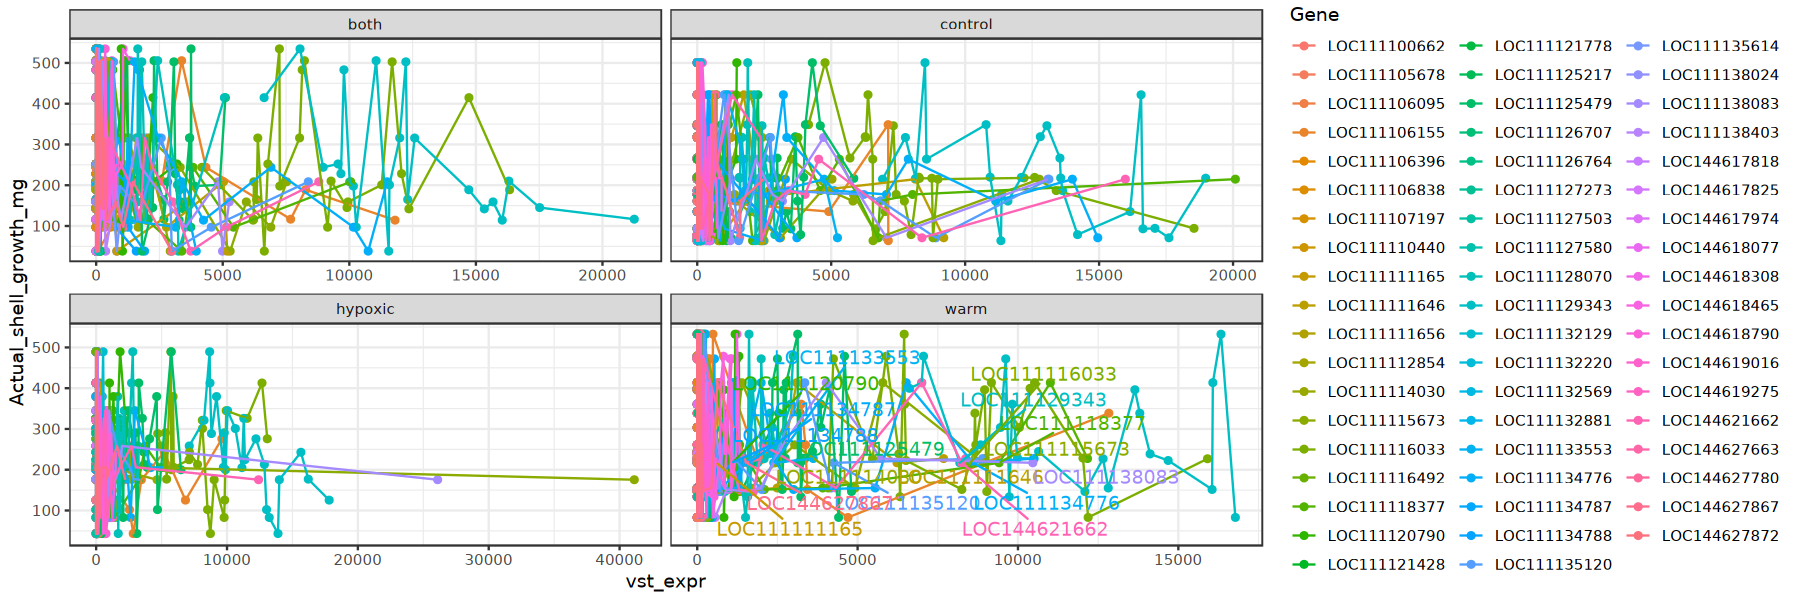

In [96]:
ggplot(chitin_core, aes(x = vst_expr, y = Actual_shell_growth_mg, col = Gene)) +
geom_point() +
geom_line() +
geom_text_repel(
    data = dplyr::filter(chitin_core, Sample == max(Sample)),
    aes(label = Gene),
    hjust = 0,
    direction = "y",
    max.overlaps = 50,
    show.legend = FALSE
  ) +
facet_wrap(~Phase1_treatment, scales = 'free_x') +
theme_bw()

picking out LOC111129343 from above - looks like it might have a negative relationship (as the expression increases, the shell growth decreases)

#### [LOC111129343](https://www.ncbi.nlm.nih.gov/gene/?term=LOC111129343)
uncharacterized, but enables chitin binding and protein binding according to GO on NCBI - located in the extracellular region

`geom_smooth()` using formula = 'y ~ x'


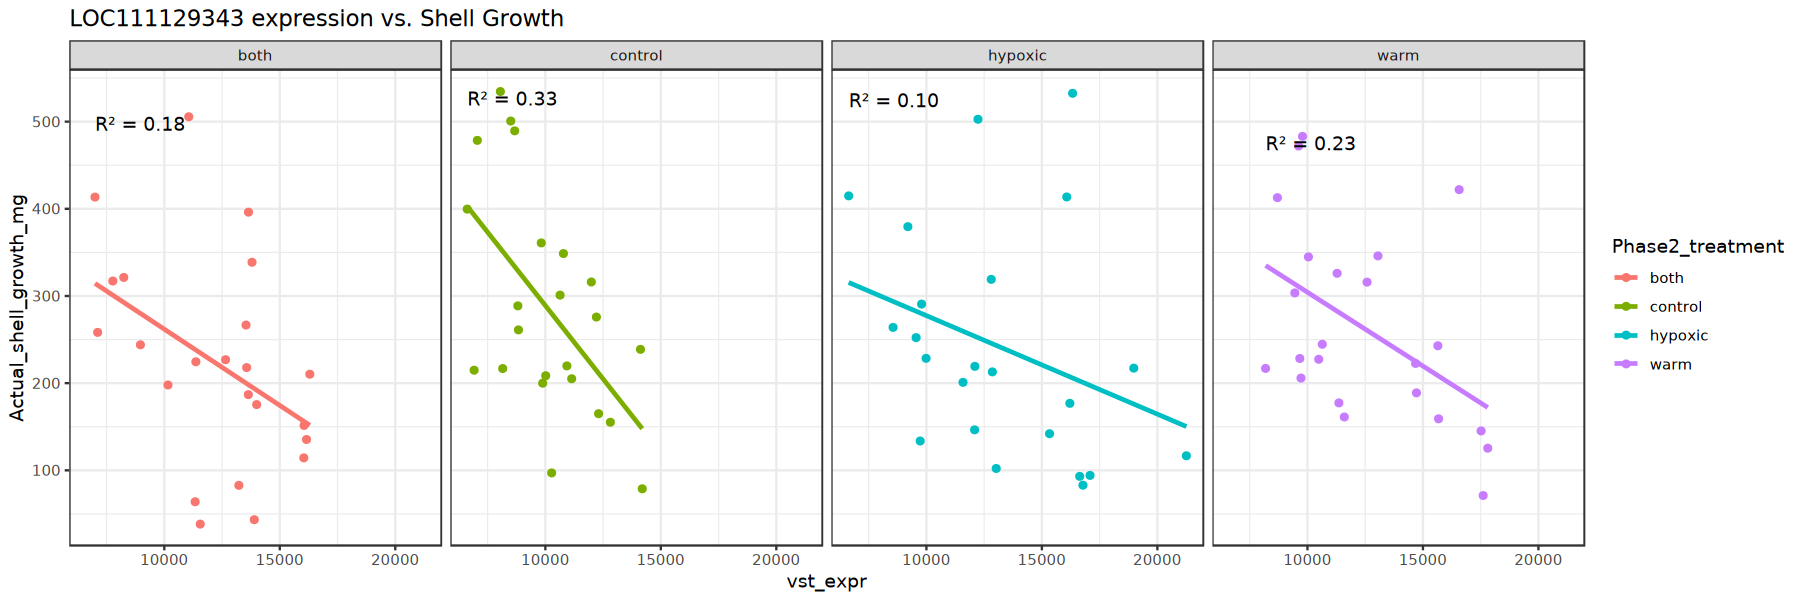

In [91]:
options(repr.plot.height = 5, repr.plot.width = 15)

r2_df <- chitin_core %>%
  filter(Gene == "LOC111129343") %>%
  group_by(Phase2_treatment) %>%
  group_modify(~{
    mod <- lm(Actual_shell_growth_mg ~ vst_expr, data = .x)
    tibble(
      r2 = glance(mod)$r.squared,
      x = min(.x$vst_expr),
      y = max(.x$Actual_shell_growth_mg)
    )
  }) %>%
  mutate(label = sprintf("R² = %.2f", r2))

ggplot(
  chitin_core %>% filter(Gene == "LOC111129343"),
  aes(x = vst_expr, y = Actual_shell_growth_mg, col = Phase2_treatment)
) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE) +
  geom_text(
    data = r2_df,
    aes(x = x, y = y, label = label),
    color = "black",
    hjust = 0,
    vjust = 1
  ) +
labs(title = 'LOC111129343 expression vs. Shell Growth') +
  facet_wrap(~Phase2_treatment, nrow = 1) +
  theme_bw()

it's interesting hat there seems to be a stronger (and less variable) relationship between the expression of this gene and shell growth -> could be an indication that in control conditions, this gene contributes to shell growth but when the oyster experiences stressors, other genes "kick in" to help maintain growth? 

`geom_smooth()` using formula = 'y ~ x'


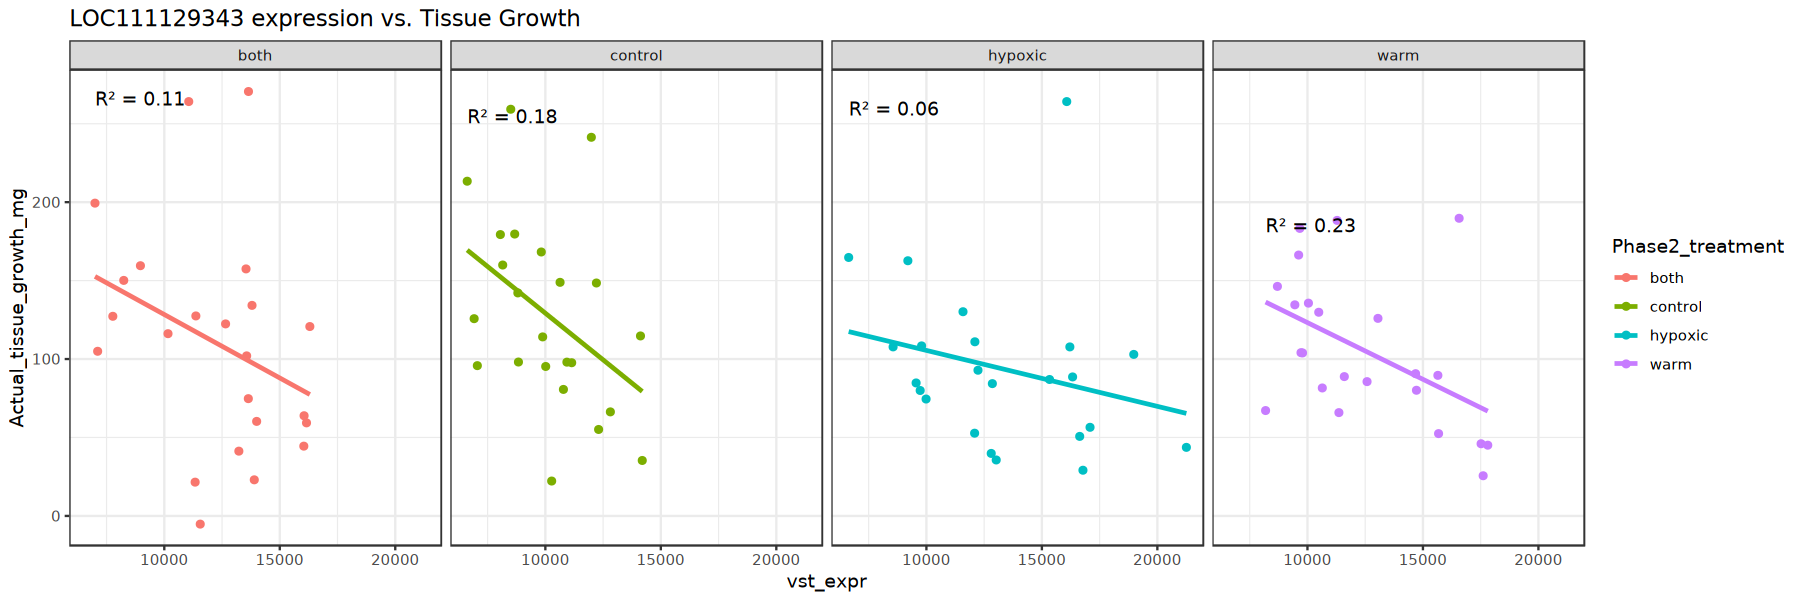

In [93]:
options(repr.plot.height = 5, repr.plot.width = 15)

r2_df_tissue <- chitin_core %>%
  filter(Gene == "LOC111129343") %>%
  group_by(Phase2_treatment) %>%
  group_modify(~{
    mod <- lm(Actual_tissue_growth_mg ~ vst_expr, data = .x)
    tibble(
      r2 = glance(mod)$r.squared,
      x = min(.x$vst_expr),
      y = max(.x$Actual_tissue_growth_mg)
    )
  }) %>%
  mutate(label = sprintf("R² = %.2f", r2))

ggplot(
  chitin_core %>% filter(Gene == "LOC111129343"),
  aes(x = vst_expr, y = Actual_tissue_growth_mg, col = Phase2_treatment)
) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE) +
  geom_text(
    data = r2_df_tissue,
    aes(x = x, y = y, label = label),
    color = "black",
    hjust = 0,
    vjust = 1
  ) +
labs(title = 'LOC111129343 expression vs. Tissue Growth') +
  facet_wrap(~Phase2_treatment, nrow = 1) +
  theme_bw()

#### [LOC111118377](https://www.ncbi.nlm.nih.gov/gene/?term=LOC111118377) - putative chitinase

`geom_smooth()` using formula = 'y ~ x'


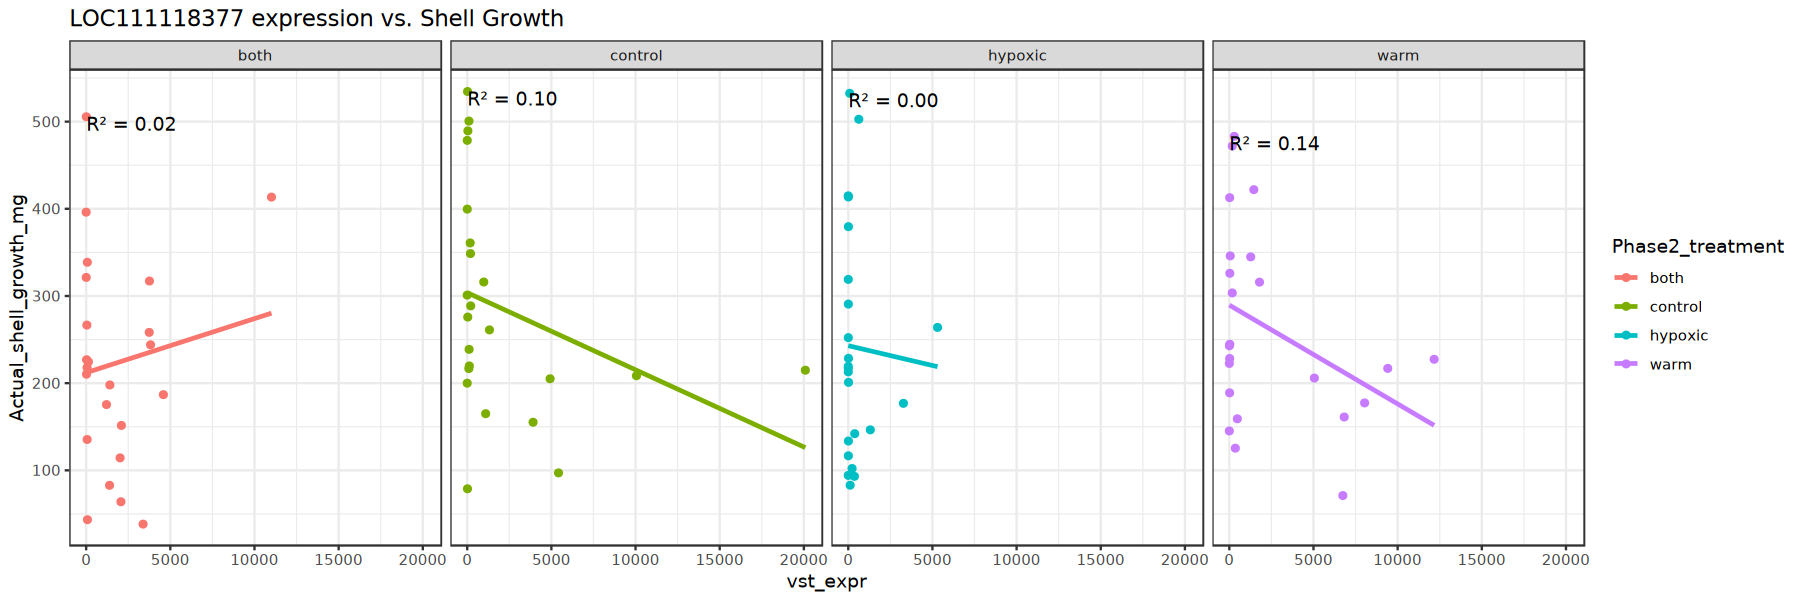

In [97]:
options(repr.plot.height = 5, repr.plot.width = 15)

r2_df <- chitin_core %>%
  filter(Gene == "LOC111118377") %>%
  group_by(Phase2_treatment) %>%
  group_modify(~{
    mod <- lm(Actual_shell_growth_mg ~ vst_expr, data = .x)
    tibble(
      r2 = glance(mod)$r.squared,
      x = min(.x$vst_expr),
      y = max(.x$Actual_shell_growth_mg)
    )
  }) %>%
  mutate(label = sprintf("R² = %.2f", r2))

ggplot(
  chitin_core %>% filter(Gene == "LOC111118377"),
  aes(x = vst_expr, y = Actual_shell_growth_mg, col = Phase2_treatment)
) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE) +
  geom_text(
    data = r2_df,
    aes(x = x, y = y, label = label),
    color = "black",
    hjust = 0,
    vjust = 1
  ) +
labs(title = 'LOC111118377 expression vs. Shell Growth') +
  facet_wrap(~Phase2_treatment, nrow = 1) +
  theme_bw()

`geom_smooth()` using formula = 'y ~ x'


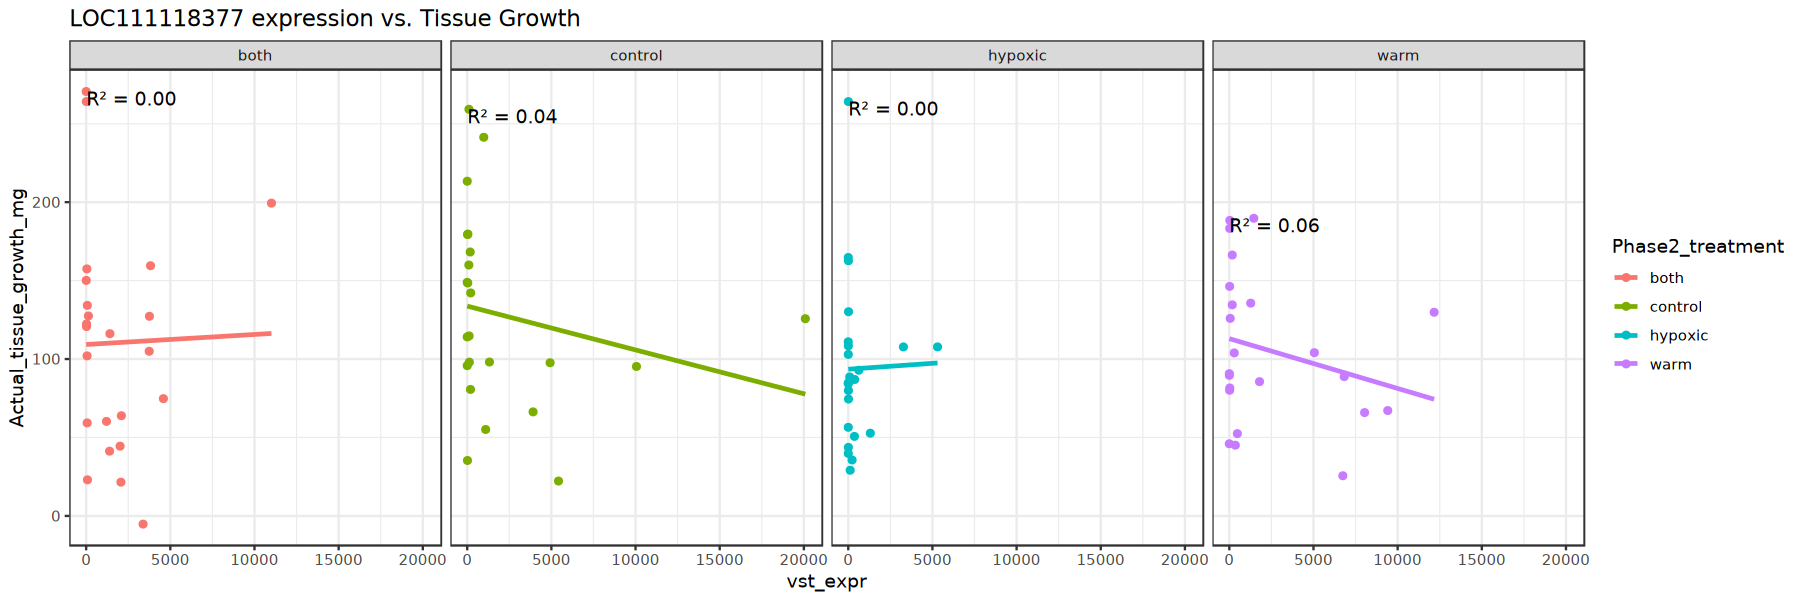

In [98]:
options(repr.plot.height = 5, repr.plot.width = 15)

r2_df <- chitin_core %>%
  filter(Gene == "LOC111118377") %>%
  group_by(Phase2_treatment) %>%
  group_modify(~{
    mod <- lm(Actual_tissue_growth_mg ~ vst_expr, data = .x)
    tibble(
      r2 = glance(mod)$r.squared,
      x = min(.x$vst_expr),
      y = max(.x$Actual_tissue_growth_mg)
    )
  }) %>%
  mutate(label = sprintf("R² = %.2f", r2))

ggplot(
  chitin_core %>% filter(Gene == "LOC111118377"),
  aes(x = vst_expr, y = Actual_tissue_growth_mg, col = Phase2_treatment)
) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE) +
  geom_text(
    data = r2_df,
    aes(x = x, y = y, label = label),
    color = "black",
    hjust = 0,
    vjust = 1
  ) +
labs(title = 'LOC111118377 expression vs. Tissue Growth') +
  facet_wrap(~Phase2_treatment, nrow = 1) +
  theme_bw()

In [106]:
colnames(chitin_core)

[1] "Sample"                  "Gene"                   
 [3] "vst_expr"                "Phase1_temp"            
 [5] "Phase1_DO"               "Phase1_treatment"       
 [7] "Phase2_temp"             "Phase2_DO"              
 [9] "Phase2_treatment"        "complete_trtmt"         
[11] "Actual_shell_growth_mg"  "Actual_tissue_growth_mg"
[13] "Ratio_tissue_shell_mg"

`geom_smooth()` using formula = 'y ~ x'


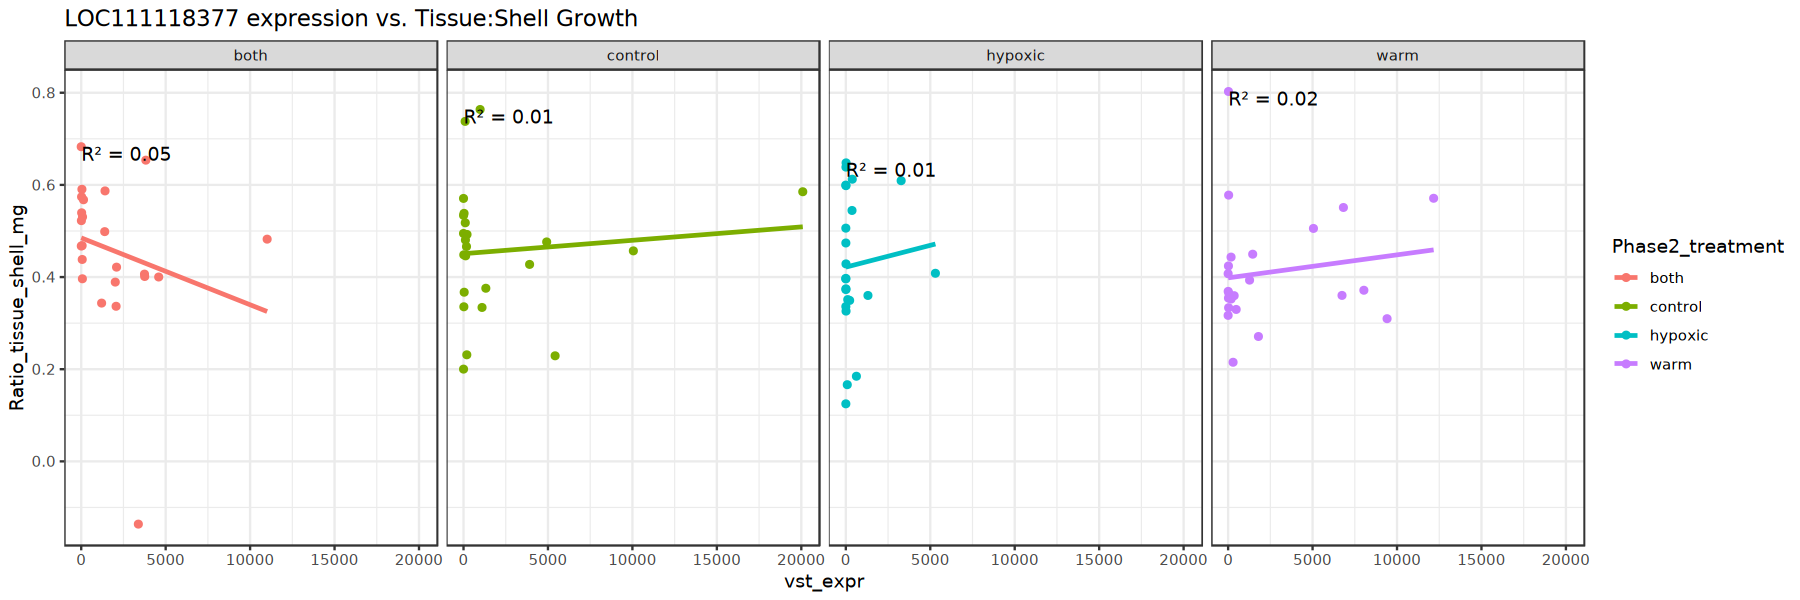

In [110]:
options(repr.plot.height = 5, repr.plot.width = 15)

chitin_core$Ratio_tissue_shell_mg <- as.numeric(chitin_core$Ratio_tissue_shell_mg)

r2_df <- chitin_core %>%
  filter(Gene == "LOC111118377") %>%
  group_by(Phase2_treatment) %>%
  group_modify(~{
    mod <- lm(Ratio_tissue_shell_mg ~ vst_expr, data = .x)
    tibble(
      r2 = glance(mod)$r.squared,
      x = min(.x$vst_expr),
      y = max(.x$Ratio_tissue_shell_mg)
    )
  }) %>%
  mutate(label = sprintf("R² = %.2f", r2))

ggplot(
  chitin_core %>% filter(Gene == "LOC111118377"),
  aes(x = vst_expr, y = Ratio_tissue_shell_mg, col = Phase2_treatment)
) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE) +
  geom_text(
    data = r2_df,
    aes(x = x, y = y, label = label),
    color = "black",
    hjust = 0,
    vjust = 1
  ) +
labs(title = 'LOC111118377 expression vs. Tissue:Shell Growth') +
  facet_wrap(~Phase2_treatment, nrow = 1) +
  theme_bw()

### tyrosinase
has been shown to be important for shell biomineralization

LOC111137992 tyrosinase-like

In [46]:
growth_data <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/growth_phase2.1_weights.csv') %>%
mutate(Sample = paste0(
    str_sub(Phase_1_treat, 1, 1), Phase_1_rep, "_",  # First letter + Phase 1 rep
    str_sub(Phase_2_treat, 1, 1), Phase_2_rep, "_",  # First letter + Phase 2 rep
    Tag_color,
    str_pad(Tag_num, width = 2, pad = "0")          # Tag number with leading zero
  )) %>%
dplyr::select(Sample, Actual_shell_growth_mg)
head(growth_data)

,Sample,Actual_shell_growth_mg
,<chr>,<dbl>
1,B1_B1_O01,210.27552
2,B1_B1_O02,269.01966
3,B1_B2_O13,418.96764
4,B1_B2_O14,285.32868
5,B1_B3_O25,75.84486
6,B1_B3_O26,182.09100


In [48]:
tyr <- file_list$bb_cc %>%
dplyr::select(-c(2:8)) %>%
  dplyr::filter(Gene == "LOC111137992") %>%
  dplyr::select(-Gene) %>%      # remove gene column
  t() %>%                   # transpose
  as.data.frame() %>%       # matrix → data.frame
  rownames_to_column("Sample") %>%
  dplyr::rename(vst_expr = V1)

dim(tyr)
head(tyr)

[1] 94  2

,Sample,vst_expr
,<chr>,<dbl>
1,B1_B1_O01,1.900755
2,B1_W5_O50,0.000000
3,B2_B5_O51,0.000000
4,B2_C4_O40,0.000000
5,B3_B4_O41,2.326916
6,B3_C3_O30,0.000000


In [49]:
tyr_growth <- merge(growth_data, tyr, by = 'Sample')
head(tyr_growth)

,Sample,Actual_shell_growth_mg,vst_expr
,<chr>,<dbl>,<dbl>
1,B1_B1_O01,210.2755,1.900755
2,B1_W5_O50,315.8883,0.000000
3,B2_B5_O51,114.3215,0.000000
4,B2_C4_O40,164.9903,0.000000
5,B3_B4_O41,197.9250,2.326916
6,B3_C3_O30,316.0466,0.000000


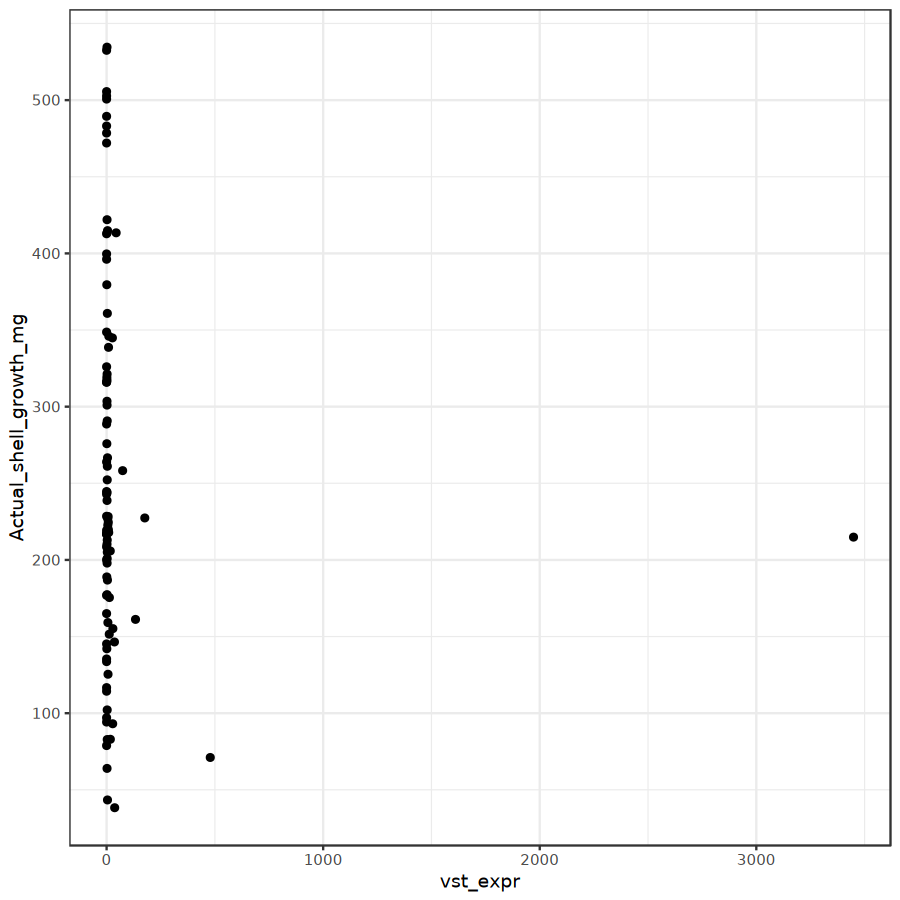

In [57]:
ggplot(tyr_growth, aes(x = vst_expr, y = Actual_shell_growth_mg)) +
geom_point() +
theme_bw()

was going to do more with this but it appears there's not really anything here ... let's see what happens when I remove that big outlier in expression

In [61]:
fit <- lm(vst_expr ~ Actual_shell_growth_mg, data = tyr_growth)
r2 <- summary(fit)$r.squared

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`).”


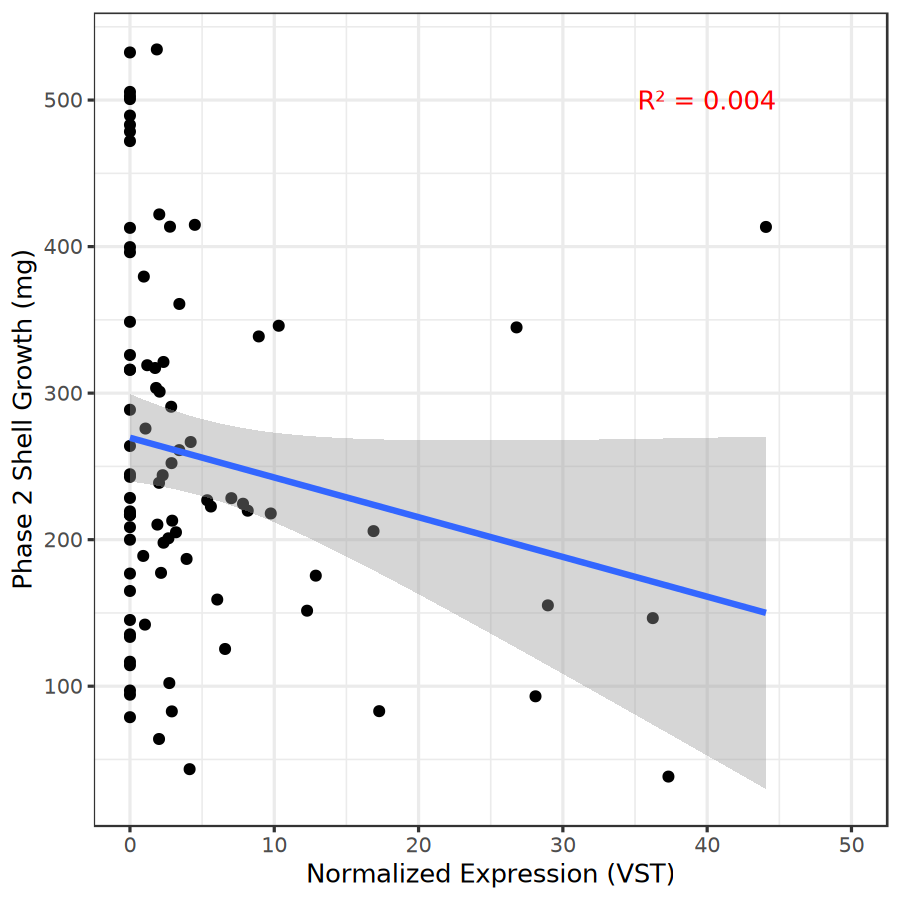

In [64]:
options(repr.plot.height = 7.5, repr.plot.width = 7.5)

ggplot(tyr_growth, aes(x = vst_expr, y = Actual_shell_growth_mg)) +
geom_point() +
geom_smooth(method = 'lm') +
 annotate(
    "text",
    x = 40,
    y = 500,
    label = paste0("R² = ", round(r2, 3)),
     col = 'red'
  ) +
xlim(c(0,50)) +
theme_bw(base_size = 15) +
labs(x = 'Normalized Expression (VST)',
     y = 'Phase 2 Shell Growth (mg)')

so not a clear pattern - kinda all over the place - the regression line does not fit the data well

### glycogen

In [81]:
glycoGO <- term2name[grep('glyco', term2name$name, ignore.case = TRUE),]
dim(glycoGO)
head(glycoGO)

[1] 19  2

,term,name
,<chr>,<chr>
GO:0004579,GO:0004579,dolichyl-diphosphooligosaccharide-protein glycotransferase activity
GO:0004373,GO:0004373,glycogen (starch) synthase activity
GO:0016757,GO:0016757,glycosyltransferase activity
GO:0005539,GO:0005539,glycosaminoglycan binding
GO:0006486,GO:0006486,protein glycosylation
GO:0006487,GO:0006487,protein N-linked glycosylation


let's just look at all of them first

In [83]:
# pull out genes related to chitinase activity
glyco_genes <- term2gene %>%
inner_join(glycoGO, by = 'term') %>%
distinct(gene, term, name)

dim(glyco_genes)
head(glyco_genes)

[1] 54  3

gene,term,name
<chr>,<chr>,<chr>
LOC111137420,GO:0004579,dolichyl-diphosphooligosaccharide-protein glycotransferase activity
LOC111135290,GO:0004373,glycogen (starch) synthase activity
LOC111124480,GO:0016757,glycosyltransferase activity
LOC111113469,GO:0005539,glycosaminoglycan binding
LOC111121072,GO:0006486,protein glycosylation
LOC111119188,GO:0005539,glycosaminoglycan binding


In [88]:
# pulling out only genes related to glycogene
glyco.genes <- combined.df[glyco_genes$gene %in% combined.df$Gene,]
dim(glyco.genes)
head(glyco.genes)

[1] 333 104

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48,pair,DEG_group
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
bb_cc.34,LOC111112463,2.225360,-17.808937,3.3715645,5.490792,4.001344e-08,4.245266e-05,9.659629e-05,0.0000,0.000000,⋯,1.246787,0.000000,0.0000000,0.0000,0.000000,0.0000,0.000000,0.000000,bb_cc,cc
bb_cc.51,LOC111133958,1203.765287,1.069059,0.2655014,-5.150038,2.604338e-07,2.093256e-04,6.648284e-02,2421.5621,988.668484,⋯,690.720241,894.071972,1299.4344207,1278.4120,1729.300935,1363.0670,880.336159,894.059867,bb_cc,bb
bb_cc.54,LOC111133942,32.839152,6.600312,9.7037361,-3.750639,1.763847e-04,3.964693e-02,2.808154e-01,0.0000,0.000000,⋯,0.000000,0.000000,0.0000000,0.0000,0.000000,0.0000,0.000000,0.000000,bb_cc,bb
bb_cc.88,LOC111129380,1020.979222,1.645930,0.3715428,-5.315047,1.066297e-07,9.752574e-05,7.150197e-03,2344.5816,858.394496,⋯,1028.599636,740.657349,776.8561177,409.0062,2557.416875,288.8324,466.894518,714.603139,bb_cc,bb
bb_cc.105,LOC111114643,4.929968,22.890795,2.7359133,-8.512377,1.704038e-17,7.532983e-14,2.047727e-13,366.8458,2.019752,⋯,4.987150,0.000000,0.9348449,0.0000,4.639305,0.0000,0.000000,4.298365,bb_cc,bb
bc_bb.1,LOC144622046,14.760203,-20.240057,3.3836635,-6.153978,7.556316e-10,3.000177e-07,5.789972e-07,0.0000,0.000000,⋯,0.000000,5.079954,0.0000000,0.0000,0.000000,0.0000,5.454375,0.000000,bc_bb,bb


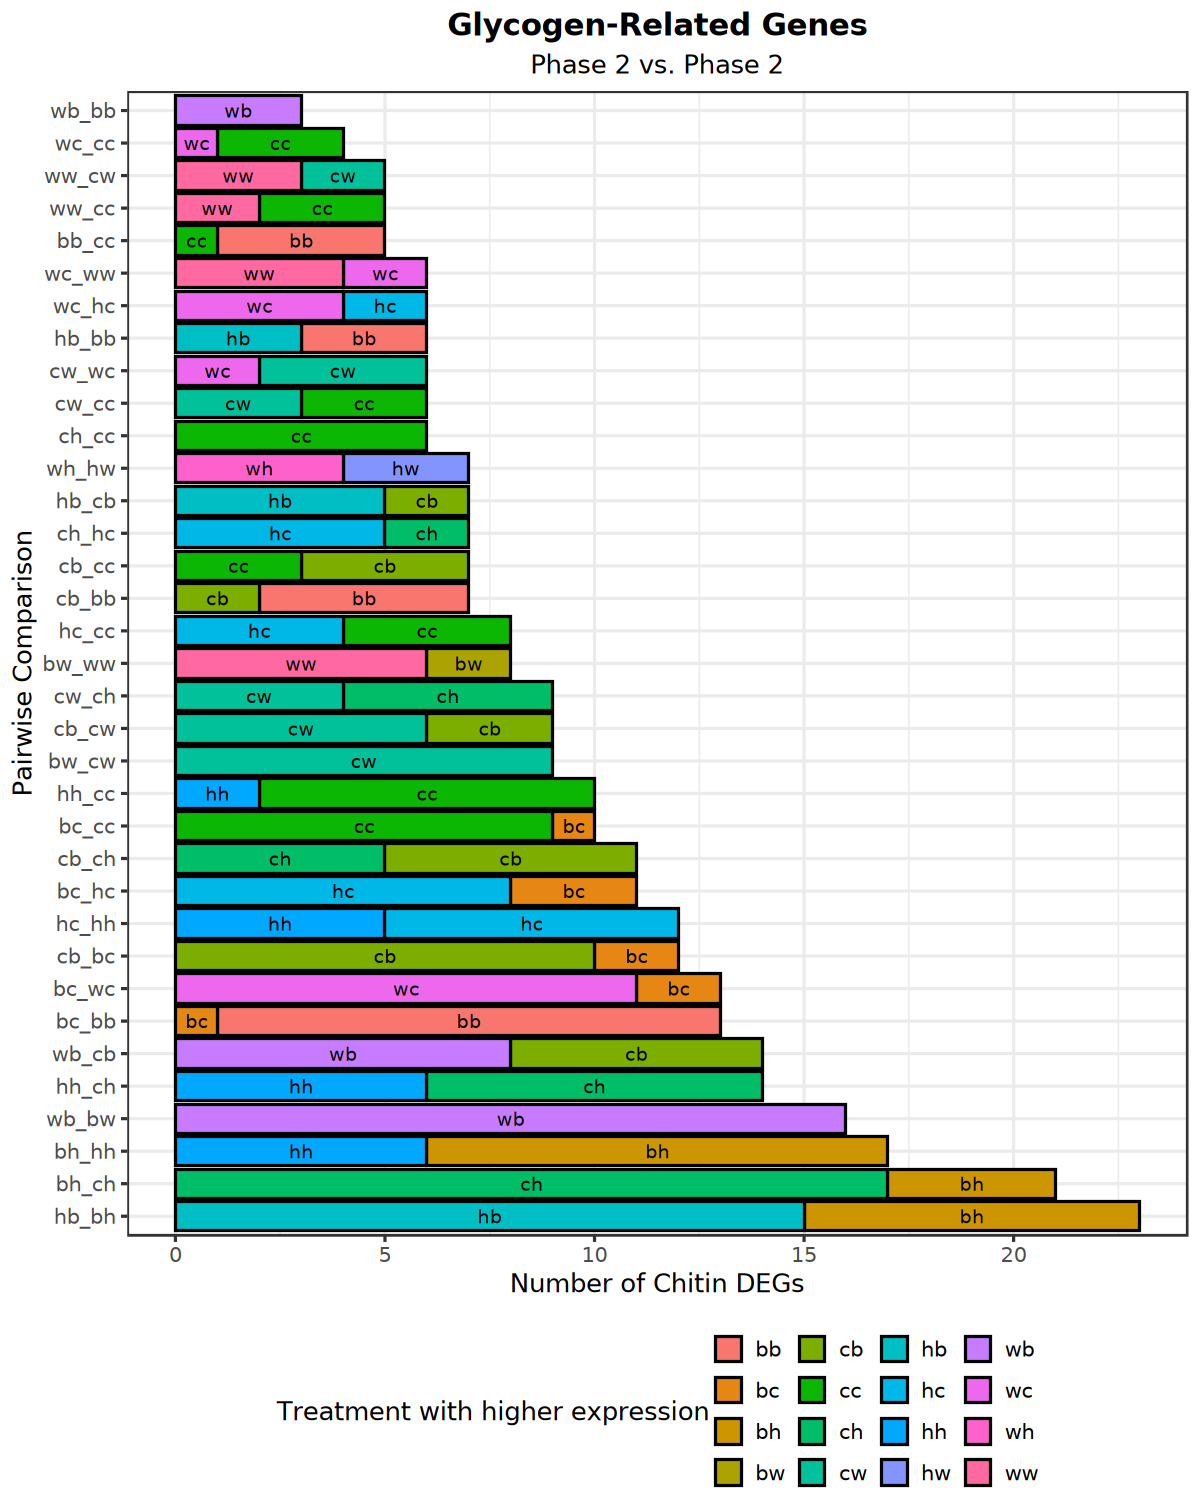

In [91]:
options(repr.plot.height = 12.6, repr.plot.width = 10)

glyco.bar <- ggplot(glyco.genes, aes(x = reorder(pair, -table(pair)[pair]), fill = DEG_group)) +
geom_bar(stat = 'count', col = 'black') + 
#scale_fill_brewer(palette='Set2') + 
theme_bw(base_size=15) +
labs(title = 'Glycogen-Related Genes',
     subtitle = 'Phase 2 vs. Phase 2',
     x = 'Pairwise Comparison',
     y = 'Number of Chitin DEGs',
    fill = 'Treatment with higher expression') +
geom_text(
    stat = "count",
    aes(label = DEG_group),
    position = position_stack(vjust = 0.5),
    color = "black",
    size = 4
  ) +
theme(legend.position = 'bottom', legend.direction = 'horizontal',
    plot.title = element_text(face = 'bold', hjust = 0.5),
     plot.subtitle = element_text(hjust = 0.5)) + 
coord_flip() 

glyco.bar

#### glycogen biosynthetic process

In [132]:
glyco_biosyn <- glyco_genes %>%
filter(name == 'glycogen biosynthetic process') %>%
pull(gene)
glyco_biosyn

glyco_biosyn.df <- norm_counts %>%
  dplyr::filter(Gene == glyco_biosyn) %>%
  dplyr::select(-Gene) %>%      # remove gene column
  t() %>%                   # transpose
  as.data.frame() %>%       # matrix → data.frame
  rownames_to_column("Sample") %>%
  dplyr::rename(norm_counts = V1) %>%
# merge with meta data
merge(metaData, by = 'Sample')

dim(glyco_biosyn.df)
head(glyco_biosyn.df)

[1] "LOC111137764"

[1] 94  9

,Sample,norm_counts,Phase1_temp,Phase1_DO,Phase1_treatment,Phase2_temp,Phase2_DO,Phase2_treatment,complete_trtmt
,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,B1_B1_O01,5531.198,warm,hypoxic,both,warm,hypoxic,both,both_both
2,B1_W5_O50,4720.160,warm,hypoxic,both,warm,normoxic,warm,both_warm
3,B2_B5_O51,2775.811,warm,hypoxic,both,warm,hypoxic,both,both_both
4,B2_C4_O40,4385.489,warm,hypoxic,both,ambient,normoxic,control,both_control
5,B3_B4_O41,5097.108,warm,hypoxic,both,warm,hypoxic,both,both_both
6,B3_C3_O30,5839.319,warm,hypoxic,both,ambient,normoxic,control,both_control


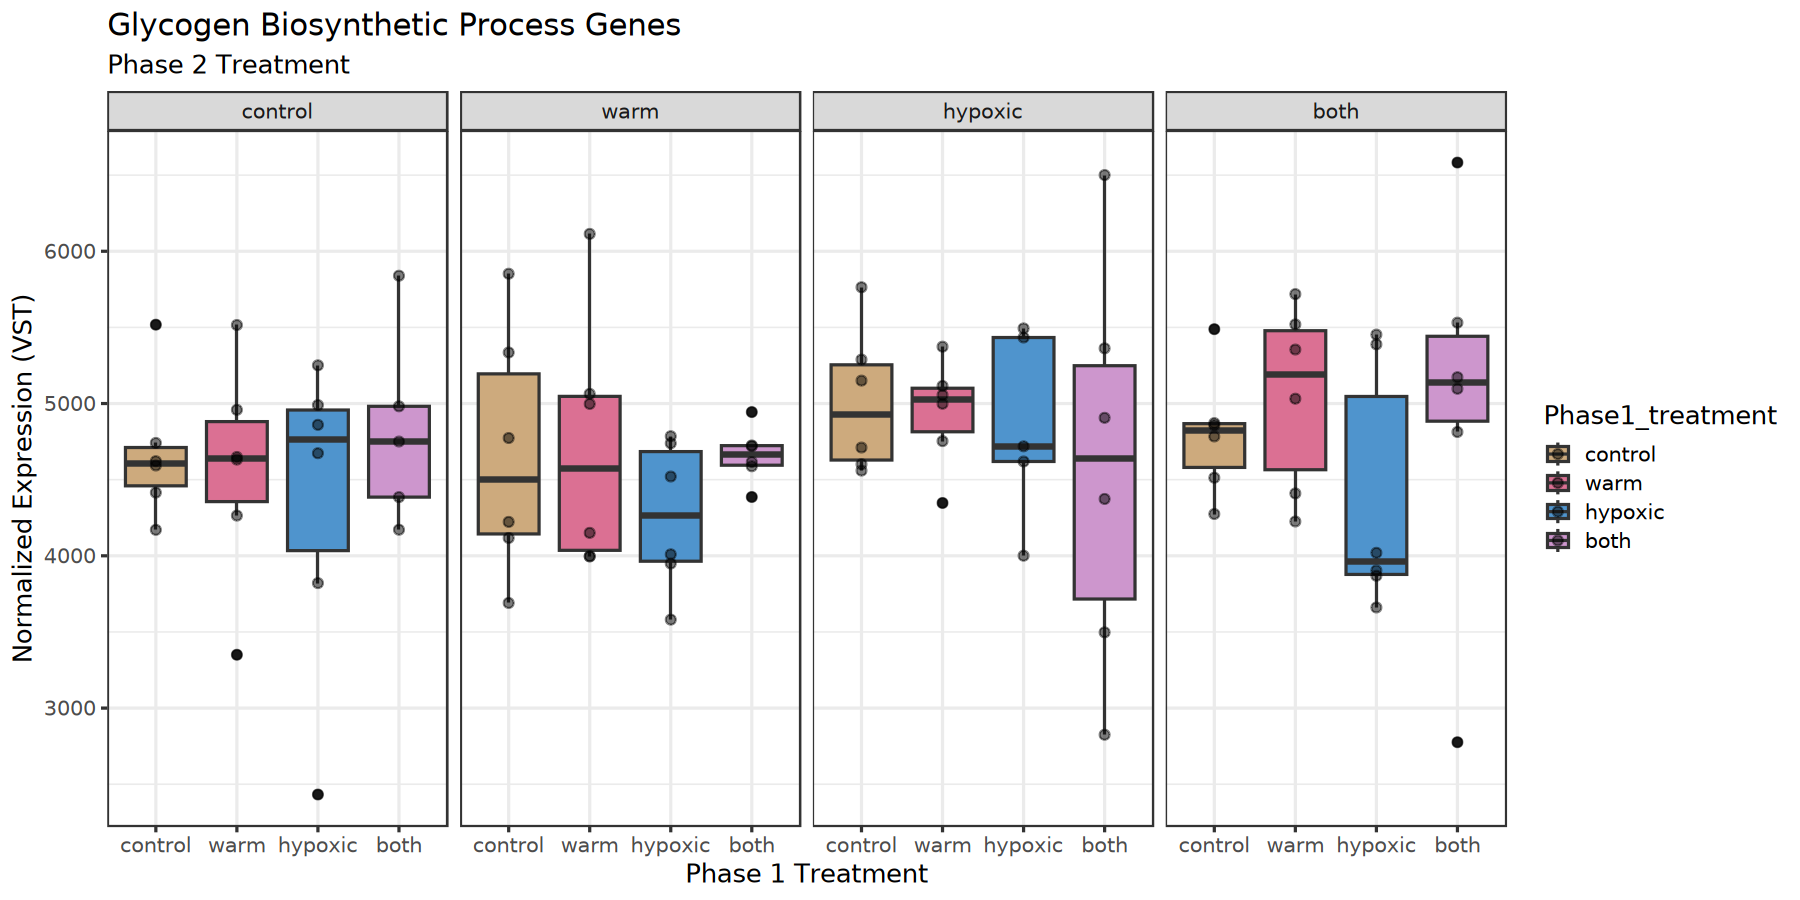

In [134]:
options(repr.plot.height = 7.5, repr.plot.width = 15)

glyco_biosyn.df$Phase1_treatment <- factor(
  glyco_biosyn.df$Phase1_treatment,
  levels = c("control", "warm", "hypoxic", "both")
)

glyco_biosyn.df$Phase2_treatment <- factor(
  glyco_biosyn.df$Phase2_treatment,
  levels = c("control", "warm", "hypoxic", "both")
)

ggplot(glyco_biosyn.df, aes(x = Phase1_treatment, y = norm_counts, fill = Phase1_treatment)) +
geom_boxplot() +
scale_fill_manual(values = c("control" = "burlywood3", "hypoxic" = "steelblue3", "warm" = "palevioletred", "both" = "plum3")) + 
geom_point(alpha = 0.5) + 
facet_wrap(~Phase2_treatment, nrow = 1) +
labs(title = 'Glycogen Biosynthetic Process Genes',
     subtitle = 'Phase 2 Treatment',
     x = 'Phase 1 Treatment',
     y = 'Normalized Expression (VST)') +
theme_bw(base_size = 15)

In [142]:
# two-way ANOVA
glycoBio.aov <- aov(norm_counts ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = glyco_biosyn.df)
summary(glycoBio.aov) 

                                            Df  Sum Sq Mean Sq F value Pr(>F)
Phase1_temp                                  1   10800   10800   0.279  0.599
Phase1_DO                                    1   86500   86500   2.235  0.139
Phase2_temp                                  1       8       8   0.000  0.989
Phase2_DO                                    1   71629   71629   1.851  0.178
Phase1_temp:Phase1_DO                        1   75275   75275   1.945  0.167
Phase1_temp:Phase2_temp                      1  106002  106002   2.739  0.102
Phase1_DO:Phase2_temp                        1    7197    7197   0.186  0.668
Phase1_temp:Phase2_DO                        1   26619   26619   0.688  0.409
Phase1_DO:Phase2_DO                          1    5267    5267   0.136  0.713
Phase2_temp:Phase2_DO                        1       7       7   0.000  0.989
Phase1_temp:Phase1_DO:Phase2_temp            1   10252   10252   0.265  0.608
Phase1_temp:Phase1_DO:Phase2_DO              1   49641   49641  

#### positive regulation of glycolytic process

In [137]:
glycolytic <- glyco_genes %>%
filter(name == 'positive regulation of glycolytic process') %>%
pull(gene)
glycolytic

glyco.df <- norm_counts %>%
  dplyr::filter(Gene == glycolytic) %>%
  dplyr::select(-Gene) %>%      # remove gene column
  t() %>%                   # transpose
  as.data.frame() %>%       # matrix → data.frame
  rownames_to_column("Sample") %>%
  dplyr::rename(norm_counts = V1) %>%
# merge with meta data
merge(metaData, by = 'Sample')

dim(glyco.df)
head(glyco.df)

[1] "LOC111121003"

[1] 94  9

,Sample,norm_counts,Phase1_temp,Phase1_DO,Phase1_treatment,Phase2_temp,Phase2_DO,Phase2_treatment,complete_trtmt
,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,B1_B1_O01,527.4596,warm,hypoxic,both,warm,hypoxic,both,both_both
2,B1_W5_O50,652.3798,warm,hypoxic,both,warm,normoxic,warm,both_warm
3,B2_B5_O51,510.7798,warm,hypoxic,both,warm,hypoxic,both,both_both
4,B2_C4_O40,1244.4475,warm,hypoxic,both,ambient,normoxic,control,both_control
5,B3_B4_O41,872.5933,warm,hypoxic,both,warm,hypoxic,both,both_both
6,B3_C3_O30,930.1260,warm,hypoxic,both,ambient,normoxic,control,both_control


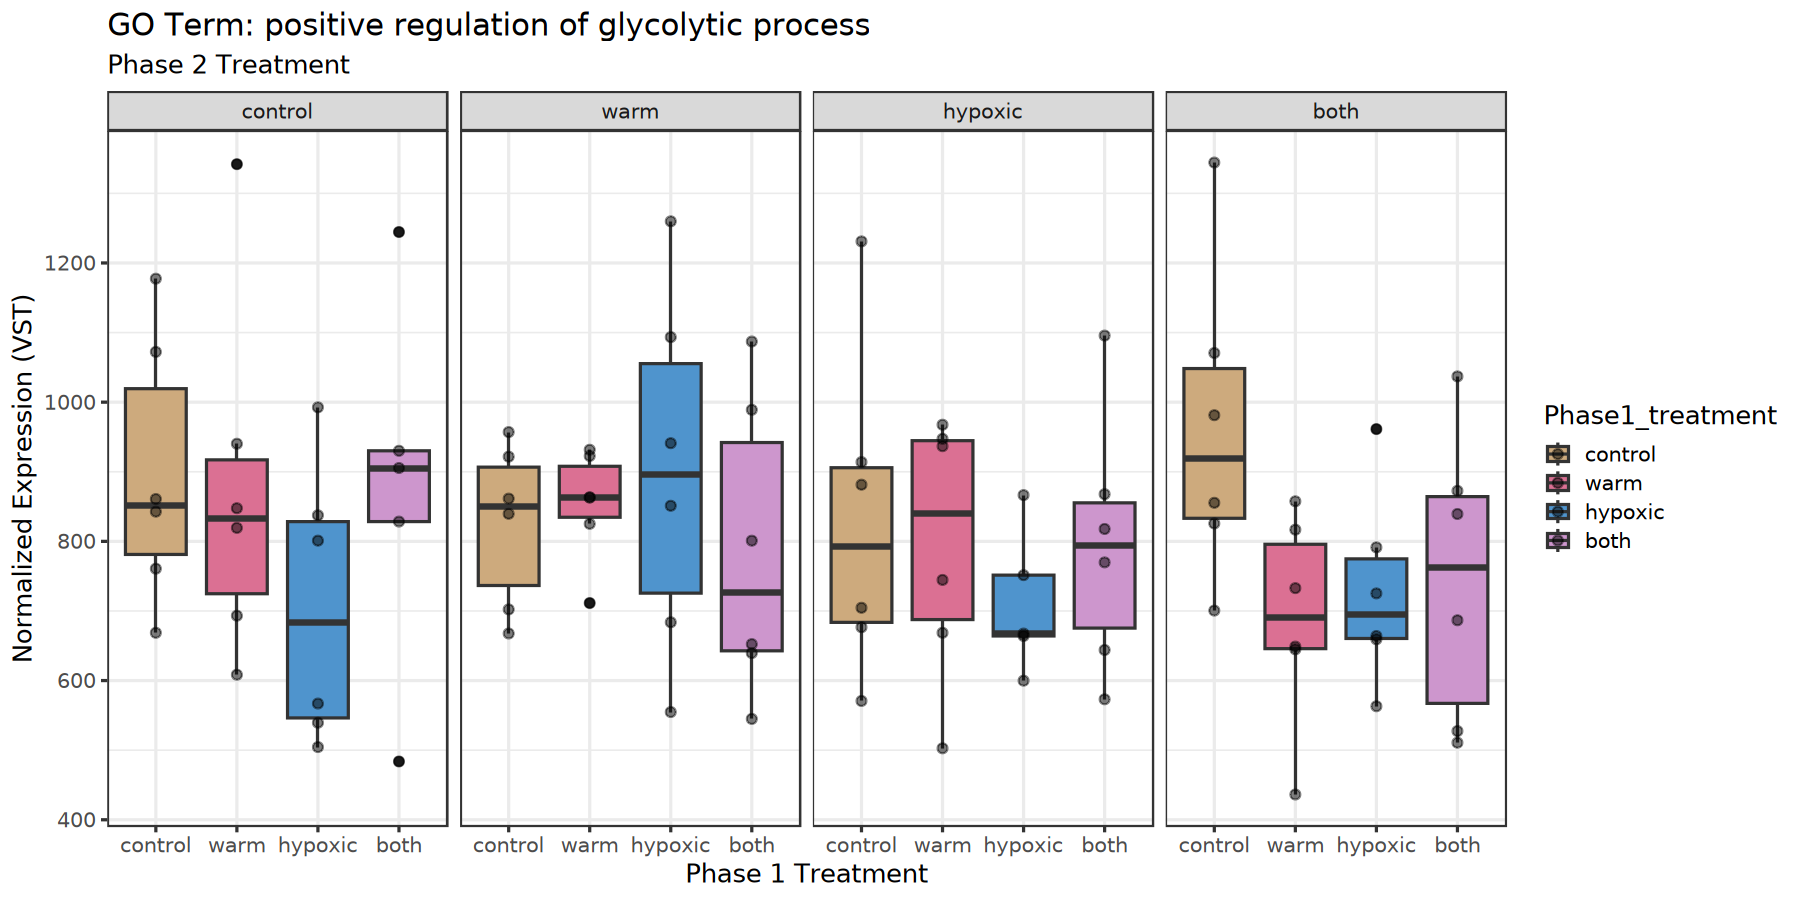

In [139]:
options(repr.plot.height = 7.5, repr.plot.width = 15)

glyco.df$Phase1_treatment <- factor(
  glyco.df$Phase1_treatment,
  levels = c("control", "warm", "hypoxic", "both")
)

glyco.df$Phase2_treatment <- factor(
  glyco.df$Phase2_treatment,
  levels = c("control", "warm", "hypoxic", "both")
)

ggplot(glyco.df, aes(x = Phase1_treatment, y = norm_counts, fill = Phase1_treatment)) +
geom_boxplot() +
scale_fill_manual(values = c("control" = "burlywood3", "hypoxic" = "steelblue3", "warm" = "palevioletred", "both" = "plum3")) + 
geom_point(alpha = 0.5) + 
facet_wrap(~Phase2_treatment, nrow = 1) +
labs(title = 'GO Term: positive regulation of glycolytic process',
     subtitle = 'Phase 2 Treatment',
     x = 'Phase 1 Treatment',
     y = 'Normalized Expression (VST)') +
theme_bw(base_size = 15)

In [141]:
# two-way ANOVA
glycolytic.aov <- aov(norm_counts ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = glyco.df)
summary(glycolytic.aov)     

                                            Df  Sum Sq Mean Sq F value Pr(>F)
Phase1_temp                                  1   10800   10800   0.279  0.599
Phase1_DO                                    1   86500   86500   2.235  0.139
Phase2_temp                                  1       8       8   0.000  0.989
Phase2_DO                                    1   71629   71629   1.851  0.178
Phase1_temp:Phase1_DO                        1   75275   75275   1.945  0.167
Phase1_temp:Phase2_temp                      1  106002  106002   2.739  0.102
Phase1_DO:Phase2_temp                        1    7197    7197   0.186  0.668
Phase1_temp:Phase2_DO                        1   26619   26619   0.688  0.409
Phase1_DO:Phase2_DO                          1    5267    5267   0.136  0.713
Phase2_temp:Phase2_DO                        1       7       7   0.000  0.989
Phase1_temp:Phase1_DO:Phase2_temp            1   10252   10252   0.265  0.608
Phase1_temp:Phase1_DO:Phase2_DO              1   49641   49641  

## 3. Stress-related genes

### response to hypoxia GO term

In [65]:
hypoxiaGO <- term2name[grep('hypoxia', term2name$name, ignore.case = TRUE),]
hypoxiaGO

,term,name
,<chr>,<chr>
GO:0001666,GO:0001666,response to hypoxia


In [66]:
# pull out genes related to chitinase activity
# GO:0001666
hyp_genes <- term2gene %>%
inner_join(hypoxiaGO, by = 'term') %>%
distinct(gene, term, name)

dim(hyp_genes) # 28 genes related to GO term "response to hypoxia"
head(hyp_genes)

[1] 28  3

gene,term,name
<chr>,<chr>,<chr>
LOC111101340,GO:0001666,response to hypoxia
LOC111113370,GO:0001666,response to hypoxia
LOC111120877,GO:0001666,response to hypoxia
LOC111120835,GO:0001666,response to hypoxia
LOC111120876,GO:0001666,response to hypoxia
LOC111121280,GO:0001666,response to hypoxia


In [67]:
# combining all dfs into one
combined.df <- do.call(rbind, deg_list)
dim(combined.df)

# pulling out only genes related to chitin
hyp_all <- combined.df[hyp_genes$gene %in% combined.df$Gene,]
dim(hyp_all)
head(hyp_all)

[1] 5998  102

[1] 214 102

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
bb_cc.14,LOC111127247,12.150561,18.666791,2.129301,-8.858087,8.139901e-19,5.227948e-15,1.272313e-14,0.9503776,1.009876,⋯,173.10149,0.8221895,0.000000,1.015991,0.00000,0.0000,0.000000,1.110894,2.18175,0.00000
bb_cc.42,LOC111100763,95.725514,-1.222357,1.025560,3.921124,8.813692e-05,2.545769e-02,9.869068e-02,48.4692580,171.678899,⋯,94.71591,402.0506468,188.264903,36.575672,155.18425,103.8576,92.786100,76.651687,83.99738,42.98365
bb_cc.70,LOC144618073,95.606407,-20.228684,2.077382,9.834204,8.019903e-23,1.063600e-18,3.387340e-18,0.0000000,253.478845,⋯,0.00000,357.6524159,0.000000,50.799544,3.73938,0.0000,0.000000,382.147541,0.00000,0.00000
bb_cc.98,LOC111114254,3.342701,7.415011,8.371085,-3.865912,1.106748e-04,2.877980e-02,1.586743e-01,2.8511328,0.000000,⋯,0.00000,0.0000000,18.701812,0.000000,0.00000,0.0000,2.319652,0.000000,0.00000,0.00000
bc_bb.19,LOC111104452,7.640312,-16.963638,3.761968,-4.923110,8.517941e-07,2.450212e-04,2.782513e-04,7.6030209,0.000000,⋯,0.00000,0.0000000,0.000000,0.000000,0.00000,0.0000,0.000000,0.000000,17.45400,10.74591
bc_bb.47,LOC111099828,63.589285,-8.084542,3.537053,-4.196214,2.714137e-05,5.426349e-03,1.370172e-02,243.2966676,0.000000,⋯,139.35214,0.0000000,2.493575,179.830385,43.93771,0.0000,0.000000,5.554470,8.72700,11.82050


In [70]:
hyp_df <- hyp_all[,c(-2:-8,-103, -104)] %>%
# long format df
  pivot_longer(
    cols = -Gene,
    names_to = "Sample",
    values_to = "vst"
  ) %>%
# merge with metadata
merge(metaData, by = 'Sample')

head(hyp_df)

,Sample,Gene,vst,Phase1_temp,Phase1_DO,Phase1_treatment,Phase2_temp,Phase2_DO,Phase2_treatment,complete_trtmt
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,B1_B1_O01,LOC111127247,0.9503776,warm,hypoxic,both,warm,hypoxic,both,both_both
2,B1_B1_O01,LOC111132315,0.0000000,warm,hypoxic,both,warm,hypoxic,both,both_both
3,B1_B1_O01,LOC144624732,0.0000000,warm,hypoxic,both,warm,hypoxic,both,both_both
4,B1_B1_O01,LOC111109661,0.0000000,warm,hypoxic,both,warm,hypoxic,both,both_both
5,B1_B1_O01,LOC111128296,17.1067969,warm,hypoxic,both,warm,hypoxic,both,both_both
6,B1_B1_O01,LOC144624866,0.0000000,warm,hypoxic,both,warm,hypoxic,both,both_both


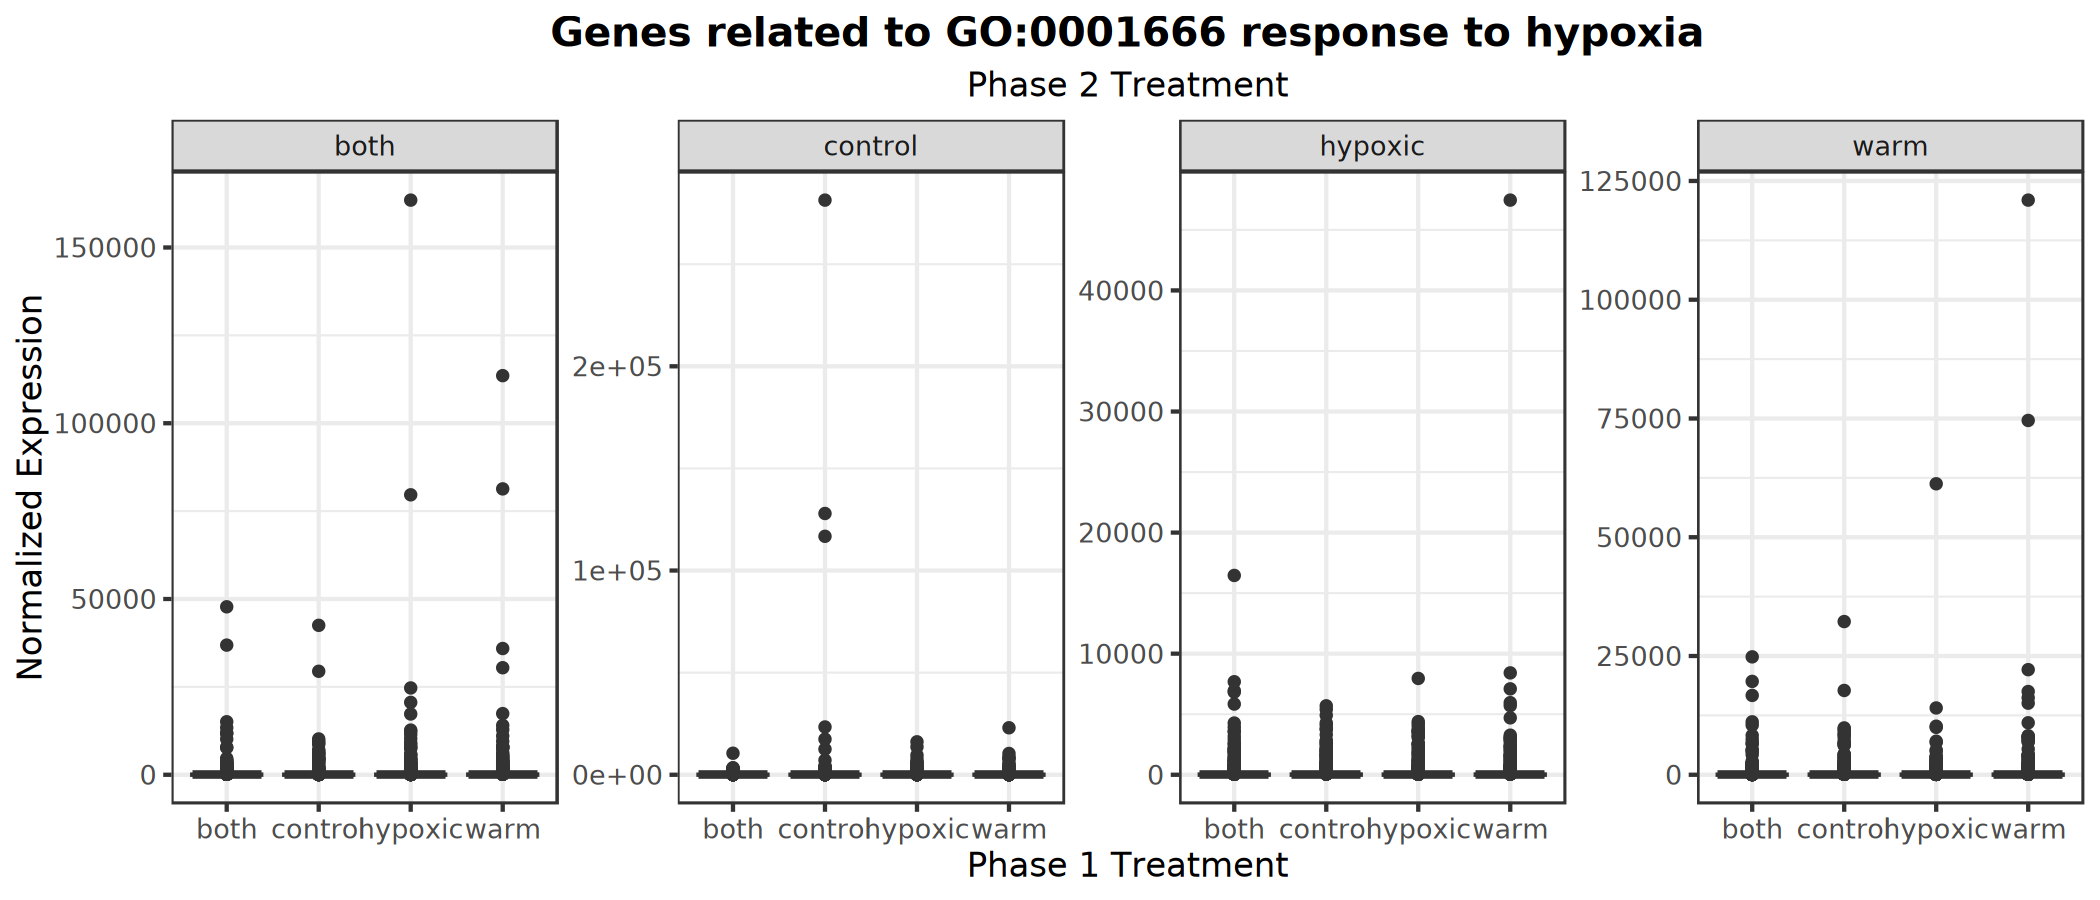

In [71]:
options(repr.plot.width=17.5, repr.plot.height=7.5)

ggplot(hyp_df, aes(x=Phase1_treatment, y = vst, fill = Phase2_treatment)) +
geom_boxplot() + 
facet_wrap(~Phase2_treatment, scale = 'free', nrow = 1) + 
scale_fill_manual(values = c("control" = "burlywood3", "hypoxic" = "steelblue3", "warm" = "palevioletred", "both" = "plum3")) + 
theme_bw(base_size = 20) +
labs(title = 'Genes related to GO:0001666 response to hypoxia',
     subtitle = 'Phase 2 Treatment',
     x = 'Phase 1 Treatment',
     y = 'Normalized Expression') +
theme(legend.position = 'none',
     plot.title = element_text(hjust = 0.5, face = 'bold'),
     plot.subtitle = element_text(hjust = 0.5))

there's 28 genes in this set, so probably getting muddled (not every gene is prob important)

### HSP70

using normalized counts - these are attached to the DESeq results, so I can choose any csv to look at bc they're all the same

In [73]:
norm_counts <- file_list$bb_cc %>%
dplyr::select(-c( baseMean, log2FoldChange, lfcSE, stat, pvalue, padj, svalue))

head(norm_counts)

,Gene,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,2495.69160,2092.46282,2064.1625,1825.307015,1404.29352,1381.734279,1986.775,1493.836374,1645.83507,⋯,2997.1598,989.093923,1560.977872,2330.6831,2070.68147,1769.86179,1994.901145,1739.660029,2926.81774,2569.347527
2,LOC144621269,52.27077,1648.11743,2375.9869,889.771163,2454.89589,1036.593201,6579.339,1502.147007,19.97642,⋯,14829.0276,3.288758,7.480725,629.9143,41.13318,108.14038,10700.556957,17.774304,417.80514,10534.217403
3,LOC111120925,66.52643,23.22715,448.6062,9.680992,17.45187,8.189788,0.000,1.038829,0.00000,⋯,375.5976,0.000000,3.740362,459.2279,76.65728,29.97951,5.799131,1.110894,11.99963,9.671321
4,Trnae-cuc-2,0.00000,0.00000,0.0000,0.000000,0.00000,0.000000,0.000,0.000000,0.00000,⋯,0.0000,0.000000,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000
5,Trnae-cuc-3,0.00000,0.00000,0.0000,0.000000,0.00000,0.000000,0.000,0.000000,0.00000,⋯,0.0000,0.000000,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000
6,LOC144621283,540.76486,870.51301,891.4734,740.155834,819.07427,1091.581780,1054.960,455.007185,683.63749,⋯,604.2222,1004.715522,771.761424,893.0560,866.60123,794.45702,586.872081,1420.833446,596.70865,618.964524


In [75]:
hsp70 <- norm_counts %>%
  dplyr::filter(Gene == "LOC111137579") %>%
  dplyr::select(-Gene) %>%      # remove gene column
  t() %>%                   # transpose
  as.data.frame() %>%       # matrix → data.frame
  rownames_to_column("Sample") %>%
  dplyr::rename(norm_counts = V1)

dim(hsp70)
head(hsp70)

[1] 94  2

,Sample,norm_counts
,<chr>,<dbl>
1,B1_B1_O01,334.5329
2,B1_W5_O50,682.6761
3,B2_B5_O51,659.0399
4,B2_C4_O40,328.2736
5,B3_B4_O41,687.6035
6,B3_C3_O30,430.5489


In [76]:
hsp70.df <- merge(hsp70, metaData, by = 'Sample')
head(hsp70.df)

,Sample,norm_counts,Phase1_temp,Phase1_DO,Phase1_treatment,Phase2_temp,Phase2_DO,Phase2_treatment,complete_trtmt
,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,B1_B1_O01,334.5329,warm,hypoxic,both,warm,hypoxic,both,both_both
2,B1_W5_O50,682.6761,warm,hypoxic,both,warm,normoxic,warm,both_warm
3,B2_B5_O51,659.0399,warm,hypoxic,both,warm,hypoxic,both,both_both
4,B2_C4_O40,328.2736,warm,hypoxic,both,ambient,normoxic,control,both_control
5,B3_B4_O41,687.6035,warm,hypoxic,both,warm,hypoxic,both,both_both
6,B3_C3_O30,430.5489,warm,hypoxic,both,ambient,normoxic,control,both_control


In [143]:
# two-way anova
hsp.aov <- aov(norm_counts ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = hsp70.df)
summary(hsp.aov)

                                            Df  Sum Sq Mean Sq F value Pr(>F)  
Phase1_temp                                  1     104     104   0.002 0.9619  
Phase1_DO                                    1   48577   48577   1.076 0.3028  
Phase2_temp                                  1  167904  167904   3.719 0.0574 .
Phase2_DO                                    1    2855    2855   0.063 0.8021  
Phase1_temp:Phase1_DO                        1    5717    5717   0.127 0.7229  
Phase1_temp:Phase2_temp                      1    4300    4300   0.095 0.7584  
Phase1_DO:Phase2_temp                        1  108526  108526   2.404 0.1251  
Phase1_temp:Phase2_DO                        1       0       0   0.000 0.9984  
Phase1_DO:Phase2_DO                          1   67046   67046   1.485 0.2267  
Phase2_temp:Phase2_DO                        1  115783  115783   2.564 0.1133  
Phase1_temp:Phase1_DO:Phase2_temp            1     356     356   0.008 0.9295  
Phase1_temp:Phase1_DO:Phase2_DO         

In [78]:
# tukey post hoc
hsp.tukey <- TukeyHSD(hsp.aov)
hsp.tukey

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = norm_counts ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = hsp70.df)

$Phase1_temp
                diff       lwr      upr     p adj
warm-ambient 2.10001 -85.16579 89.36581 0.9619114

$Phase1_DO
                      diff       lwr      upr     p adj
normoxic-hypoxic -45.47581 -132.7614 41.80975 0.3028326

$Phase2_temp
                 diff       lwr     upr     p adj
warm-ambient 84.52643 -2.759129 171.812 0.0575055

$Phase2_DO
                     diff       lwr      upr     p adj
normoxic-hypoxic 11.01962 -76.24618 98.28542 0.8021682

$`Phase1_temp:Phase1_DO`
                                      diff       lwr      upr     p adj
warm:hypoxic-ambient:hypoxic      18.02968 -146.4714 182.5308 0.9916345
ambient:normoxic-ambient:hypoxic -29.87800 -192.6565 132.9005 0.9628974
warm:normoxic-ambient:hypoxic    -43.04393 -205.8224 119.7346 0.8990111
ambient:normoxic-warm:hypoxic    -4

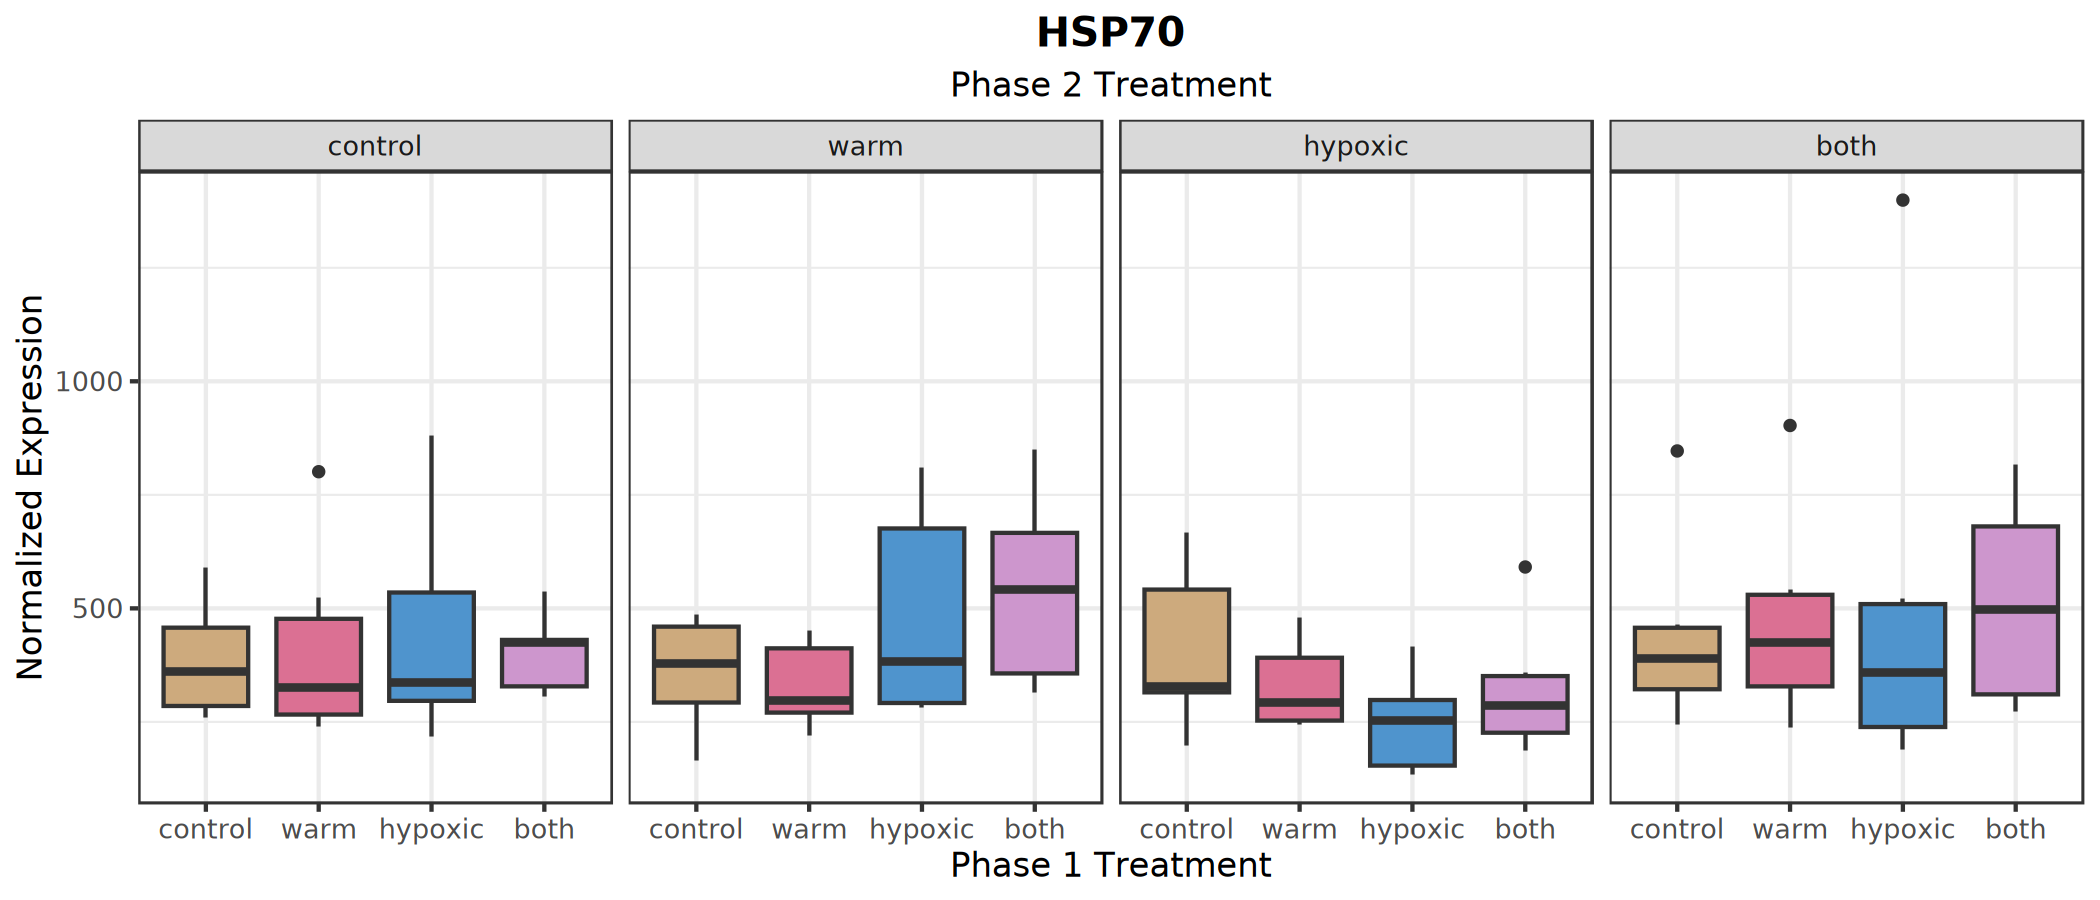

In [79]:
options(repr.plot.width=17.5, repr.plot.height=7.5)

# add factor to treatments for plotting order
hsp70.df$Phase1_treatment <- factor(hsp70.df$Phase1_treatment, c('control', 'warm', 'hypoxic', 'both'))
hsp70.df$Phase2_treatment <- factor(hsp70.df$Phase2_treatment, c('control', 'warm', 'hypoxic', 'both'))

# plotting
hsp_box <- ggplot(hsp70.df, aes(x=Phase1_treatment, y=norm_counts, fill = Phase1_treatment)) +
geom_boxplot() + 
facet_wrap(~Phase2_treatment, nrow = 1) + 
scale_fill_manual(values = c("control" = "burlywood3", "hypoxic" = "steelblue3", "warm" = "palevioletred", "both" = "plum3")) + 
theme_bw(base_size = 20) +
labs(title = 'HSP70',
     subtitle = 'Phase 2 Treatment',
     x = 'Phase 1 Treatment',
     y = 'Normalized Expression') +
theme(legend.position = 'none',
     plot.title = element_text(hjust = 0.5, face = 'bold'),
     plot.subtitle = element_text(hjust = 0.5))

hsp_box

In [13]:
# ggsave('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/plots/hsp70_normExpr_boxplot.pdf', hsp_box, width = 17.5, height = 7.5)